# 00A — Build and Validate the Canonical TMD Radar Teaching Dataset

**Instructor-only notebook**

**Course:** TMD Weather Radar Processing with Open-Source Python  
**Teaching radar:** Phitsanulok (PHS) weather radar  
**Platform:** Google Colab + Google Drive  
**Dataset release:** `v1`

---

## Why this notebook exists

The lesson notebooks `01–13` should not depend on live external data services during class.

This notebook therefore separates **data acquisition** from **student analysis**:

```text
External sources
      ↓
00A Instructor Builder
      ↓
Download + validation + standardization
      ↓
Canonical TMD Radar Teaching Dataset v1
      ↓
ZIP packages + SHA256 + provenance
      ↓
Instructor uploads packages to the course GitHub repository
      ↓
00B Student Installer
      ↓
MyDrive/tmd_radar_course/
      ↓
Notebook 01–13
```

### Design principle

> **00A may access external sources. Notebook 00B and Notebook 01–13 should use only the frozen course dataset.**

The purpose is reproducibility: every student analyzes the same radar volumes, DEM, sounding and GIS layers.

---

## Compatibility target

This builder preserves the data contract already used by the existing lessons.

The future student workspace is:

```text
/content/drive/MyDrive/tmd_radar_course/
```

and will contain both:

```text
00_config/course_config.json
9config/course_paths.py
```

so that both the newer and legacy lesson-startup patterns remain supported.

---

## Important redistribution note

This notebook prepares files for a public teaching repository, but **technical packaging does not itself grant redistribution rights**.

Before publishing the generated ZIP files, the instructor should review the current license/data-use conditions of every source, especially the TMD radar files.

The final acceptance table therefore contains an explicit manual redistribution-rights check.

# 0. Data contract preserved for Notebook 01–13

The canonical dataset will provide at least:

| Resource | Canonical path |
|---|---|
| PHS radar 10:00 UTC | `01_data/radar/uf/PHS240@201807201000.uf` |
| PHS radar 10:30 UTC | `01_data/radar/uf/PHS240@201807201030.uf` |
| DEM | `01_data/dem/raw/wrl_dem_phk1.tif` |
| Raw teaching sounding | `01_data/sounding/raw/sounding_cm.txt` |
| Processed sounding | `01_data/sounding/processed/sounding_cm_profile.csv` |
| Thailand provinces | `01_data/gis/administrative/thailand_provinces.gpkg` |
| PHS-domain provinces | `01_data/gis/administrative/phs_radar_provinces.gpkg` |
| Phitsanulok amphoe | `01_data/gis/administrative/phitsanulok_amphoe.gpkg` |
| PHS sub-basins | `01_data/gis/subbasins_phs/phs_subbasins_hybas07.gpkg` |
| Radar site | `01_data/gis/radar_site/phs_radar_site.gpkg` |
| Range rings | `01_data/gis/radar_domain/phs_radar_range_rings.gpkg` |
| Radar domain | `01_data/gis/radar_domain/phs_radar_domain.gpkg` |

`00B` will create empty output/exercise/export folders for each student and will write `setup_status.json`.

## 1. Install libraries

In [1]:
# CELL 1 — Install the build environment

import sys
import subprocess

if sys.version_info < (3, 11):
    raise RuntimeError(
        f"Python 3.11+ is required; found {sys.version.split()[0]}"
    )

RIOXARRAY_SPEC = (
    "rioxarray==0.22.0"
    if sys.version_info >= (3, 12)
    else "rioxarray==0.21.0"
)

PACKAGE_SPECS = [
    "arm-pyart==2.2.5",
    "wradlib==2.9.4",
    "geopandas>=1.0",
    RIOXARRAY_SPEC,
    "cartopy>=0.24",
    "rasterio>=1.4",
    "shapely>=2.0",
    "pyproj>=3.6",
    "pyogrio>=0.10",
    "metpy>=1.6",
    "cmweather>=0.3",
    "requests>=2.31",
    "tqdm>=4.66",
    "netCDF4",
]

cmd = [
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "--upgrade-strategy",
    "only-if-needed",
    *PACKAGE_SPECS,
]

print("Installing build libraries ...")
subprocess.check_call(cmd)
print("Build environment installed.")

Installing build libraries ...
Build environment installed.


## 2. Imports and environment

In [2]:
# CELL 2 — Imports

from __future__ import annotations

import bz2
import gzip
import hashlib
import importlib.metadata as importlib_metadata
import json
import math
import os
import platform
import re
import shutil
import sys
import tempfile
import textwrap
import time
import warnings
import zipfile

from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

import geopandas as gpd
import pyart
import rasterio
import wradlib

from pyproj import CRS, Transformer
from rasterio.transform import from_origin
from shapely.geometry import Point
from shapely.ops import unary_union

warnings.filterwarnings("ignore", category=UserWarning)

print(f"Python    : {sys.version.split()[0]}")
print(f"Py-ART    : {pyart.__version__}")
print(f"wradlib   : {wradlib.__version__}")
print(f"GeoPandas : {gpd.__version__}")
print(f"Rasterio  : {rasterio.__version__}")


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly supported
## by the U.S. Department of Energy Office of Science as part of
## the Atmospheric Radiation Measurement (ARM) User Facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119

Python    : 3.13.15
Py-ART    : 2.2.5
wradlib   : 2.9.4
GeoPandas : 1.1.4
Rasterio  : 1.5.1


## 3. Mount Google Drive and define release settings

In [3]:
# CELL 3 — Mount Drive and configuration

from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=False,
)

COURSE_NAME = (
    "TMD Weather Radar Processing with Open-Source Python"
)

COURSE_VERSION = "1.0.0"
DATASET_VERSION = "v1"

# Canonical student workspace required by legacy notebooks.
STUDENT_WORKSPACE_NAME = "tmd_radar_course"
STUDENT_ROOT = (
    Path("/content/drive/MyDrive")
    / STUDENT_WORKSPACE_NAME
)

# Instructor-only build area.
BUILDER_BASE = Path(
    "/content/drive/MyDrive/TMD_Radar_Course_Builder"
)

BUILD_ROOT = (
    BUILDER_BASE
    / "00_instructor_build"
    / DATASET_VERSION
)

SOURCE_DOWNLOAD_DIR = (
    BUILD_ROOT
    / "source_downloads"
)

TEMP_DIR = (
    Path("/content")
    / f"TMD_Radar_Course_Builder_{DATASET_VERSION}"
)

CANONICAL_ROOT = (
    BUILD_ROOT
    / f"Canonical_TMD_Radar_Course_{DATASET_VERSION}"
    / STUDENT_WORKSPACE_NAME
)

GITHUB_READY_DIR = (
    BUILDER_BASE
    / "01_GitHub_ready"
    / DATASET_VERSION
)

FORCE_DOWNLOAD = False
FORCE_REBUILD_PACKAGES = True

HYDROBASINS_LEVEL = 7
STANDARD_RANGE_RINGS_KM = [50, 100, 150, 200]
FALLBACK_RADAR_RANGE_KM = 240.0

# Regular Git/GitHub hard limit is 100 MB per file.
# We use 95 MB as an operational safety threshold.
GITHUB_PACKAGE_LIMIT_MB = 95.0

# Set True only after the instructor has reviewed the current
# redistribution/license conditions of ALL source datasets.
REDISTRIBUTION_RIGHTS_CONFIRMED = False

for folder in [
    BUILD_ROOT,
    SOURCE_DOWNLOAD_DIR,
    TEMP_DIR,
    CANONICAL_ROOT,
    GITHUB_READY_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

print("Dataset version :", DATASET_VERSION)
print("Build root      :", BUILD_ROOT)
print("Canonical root  :", CANONICAL_ROOT)
print("GitHub-ready    :", GITHUB_READY_DIR)
print("Student root    :", STUDENT_ROOT)

Mounted at /content/drive
Dataset version : v1
Build root      : /content/drive/MyDrive/TMD_Radar_Course_Builder/00_instructor_build/v1
Canonical root  : /content/drive/MyDrive/TMD_Radar_Course_Builder/00_instructor_build/v1/Canonical_TMD_Radar_Course_v1/tmd_radar_course
GitHub-ready    : /content/drive/MyDrive/TMD_Radar_Course_Builder/01_GitHub_ready/v1
Student root    : /content/drive/MyDrive/tmd_radar_course


## 4. Canonical folder structure

Only common teaching inputs and metadata belong in the canonical dataset.

Student-specific outputs are **not** frozen into the packages.

In [4]:
# CELL 4 — Build canonical directory tree

CANONICAL_DIRS = [
    "00_config",
    "01_data/radar/compressed",
    "01_data/radar/uf",
    "01_data/sounding/raw",
    "01_data/sounding/processed",
    "01_data/dem/raw",
    "01_data/dem/processed",
    "01_data/gis/administrative",
    "01_data/gis/subbasins_phs",
    "01_data/gis/radar_site",
    "01_data/gis/radar_domain",
    "01_data/metadata",
    "9config",
]

PATHS = {
    rel: CANONICAL_ROOT / rel
    for rel in CANONICAL_DIRS
}

for path in PATHS.values():
    path.mkdir(
        parents=True,
        exist_ok=True,
    )

print(
    "Canonical directories:",
    len(PATHS),
)

Canonical directories: 13


## 5. Download, checksum and archive helpers

In [5]:
# CELL 5 — System helpers
#
# IMPORTANT:
# Do NOT trust a radar filename extension.
# A file named *.bz2 may contain a true bzip2 stream, gzip stream,
# raw radar bytes, a Git LFS pointer, or an HTML error/download page.
# Always inspect content before decompression.

def utc_now_iso() -> str:
    return datetime.now(
        timezone.utc
    ).isoformat()


def sha256_file(
    path: Path,
    chunk_size: int = 1024 * 1024,
) -> str:
    path = Path(path)

    digest = hashlib.sha256()

    with path.open("rb") as stream:
        for chunk in iter(
            lambda: stream.read(chunk_size),
            b"",
        ):
            digest.update(chunk)

    return digest.hexdigest()


def size_mb(path: Path) -> float:
    return (
        Path(path).stat().st_size
        / 1024**2
    )


def write_json(
    data: Any,
    path: Path,
) -> None:
    path = Path(path)
    path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    with path.open(
        "w",
        encoding="utf-8",
    ) as stream:
        json.dump(
            data,
            stream,
            ensure_ascii=False,
            indent=2,
            default=str,
        )


def read_magic(
    path: Path,
    n: int = 64,
) -> bytes:
    path = Path(path)

    with path.open(
        "rb"
    ) as stream:
        return stream.read(
            n
        )


def classify_radar_payload(
    path: Path,
) -> str:
    """
    Classify the actual byte stream.

    Returns one of:
    - BZIP2
    - GZIP
    - GIT_LFS_POINTER
    - HTML
    - TEXT_ERROR
    - RAW_OR_OTHER_BINARY

    The final proof that RAW_OR_OTHER_BINARY is a radar file is
    the Py-ART reopen test after materialization.
    """

    head = read_magic(
        path,
        256,
    )

    if head[:3] == b"BZh":
        return "BZIP2"

    if head[:2] == b"\x1f\x8b":
        return "GZIP"

    lower = (
        head
        .lstrip()
        .lower()
    )

    if lower.startswith(
        b"version https://git-lfs.github.com/spec/v1"
    ):
        return "GIT_LFS_POINTER"

    if (
        lower.startswith(
            b"<!doctype html"
        )
        or lower.startswith(
            b"<html"
        )
        or b"<html" in lower[:128]
    ):
        return "HTML"

    # Common text error responses from hosting services.
    text_error_tokens = [
        b"404: not found",
        b"not found",
        b"access denied",
        b"rate limit",
        b"bad gateway",
    ]

    if any(
        token in lower[:200]
        for token in text_error_tokens
    ):
        return "TEXT_ERROR"

    return "RAW_OR_OTHER_BINARY"


def validate_radar_download(
    path: Path,
) -> tuple[bool, str]:
    """
    Lightweight validation immediately after download.
    It deliberately accepts raw/other binary because final validation
    is performed by Py-ART after the stream is materialized to UF.
    """

    path = Path(path)

    if not path.exists():
        return (
            False,
            "file does not exist",
        )

    if path.stat().st_size < 1000:
        return (
            False,
            "file is too small",
        )

    payload_kind = (
        classify_radar_payload(
            path
        )
    )

    invalid_kinds = {
        "GIT_LFS_POINTER",
        "HTML",
        "TEXT_ERROR",
    }

    if payload_kind in invalid_kinds:
        return (
            False,
            (
                "invalid downloaded payload: "
                + payload_kind
            ),
        )

    return (
        True,
        payload_kind,
    )


def make_http_session() -> requests.Session:
    retry = Retry(
        total=5,
        connect=5,
        read=5,
        backoff_factor=1.0,
        status_forcelist=(
            429,
            500,
            502,
            503,
            504,
        ),
        allowed_methods=frozenset(
            ["GET", "HEAD"]
        ),
    )

    adapter = HTTPAdapter(
        max_retries=retry
    )

    session = requests.Session()
    session.mount(
        "https://",
        adapter,
    )
    session.mount(
        "http://",
        adapter,
    )

    session.headers.update({
        "User-Agent": (
            "TMD-Radar-Course-Canonical-Builder/"
            f"{COURSE_VERSION}"
        )
    })

    return session


HTTP = make_http_session()


def download_file(
    urls: str | Iterable[str],
    destination: Path,
    *,
    min_bytes: int = 1,
    force: bool = False,
    timeout: int = 180,
    validator=None,
) -> dict[str, Any]:

    destination = Path(
        destination
    )

    destination.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    url_list = (
        [urls]
        if isinstance(urls, str)
        else list(urls)
    )

    # ----------------------------------------------------------
    # Cached file:
    # never trust "exists" alone. Validate the cached payload.
    # ----------------------------------------------------------
    if (
        destination.exists()
        and destination.stat().st_size
        >= min_bytes
        and not force
    ):

        cache_valid = True
        cache_detail = "size check only"

        if validator is not None:
            cache_valid, cache_detail = (
                validator(
                    destination
                )
            )

        if cache_valid:
            return {
                "status":
                    "cached_verified",
                "url":
                    None,
                "final_url":
                    None,
                "content_type":
                    None,
                "validation_detail":
                    cache_detail,
                "path":
                    str(destination),
                "size_bytes":
                    destination.stat().st_size,
                "size_mb":
                    size_mb(destination),
                "sha256":
                    sha256_file(destination),
                "magic_hex":
                    read_magic(
                        destination,
                        8,
                    ).hex(),
            }

        print(
            "Cached file failed validation; "
            "removing and downloading again:"
        )
        print(
            destination
        )
        print(
            "Reason:",
            cache_detail,
        )

        destination.unlink(
            missing_ok=True
        )

    errors = []

    part_path = Path(
        str(destination)
        + ".part"
    )

    for url in url_list:

        try:
            if part_path.exists():
                part_path.unlink()

            print(
                "Downloading:",
                destination.name,
            )

            with HTTP.get(
                url,
                stream=True,
                timeout=timeout,
                allow_redirects=True,
            ) as response:

                response.raise_for_status()

                final_url = str(
                    response.url
                )

                content_type = (
                    response.headers.get(
                        "Content-Type",
                        ""
                    )
                )

                with part_path.open(
                    "wb"
                ) as output:

                    for chunk in (
                        response.iter_content(
                            chunk_size=1024 * 1024
                        )
                    ):
                        if chunk:
                            output.write(
                                chunk
                            )

            if (
                part_path.stat().st_size
                < min_bytes
            ):
                raise IOError(
                    "Downloaded file is smaller "
                    "than the minimum expected size."
                )

            validation_detail = (
                "size check only"
            )

            if validator is not None:
                valid, validation_detail = (
                    validator(
                        part_path
                    )
                )

                if not valid:
                    raise IOError(
                        validation_detail
                    )

            part_path.replace(
                destination
            )

            return {
                "status":
                    "downloaded_verified",
                "url":
                    url,
                "final_url":
                    final_url,
                "content_type":
                    content_type,
                "validation_detail":
                    validation_detail,
                "path":
                    str(destination),
                "size_bytes":
                    destination.stat().st_size,
                "size_mb":
                    size_mb(destination),
                "sha256":
                    sha256_file(destination),
                "magic_hex":
                    read_magic(
                        destination,
                        8,
                    ).hex(),
            }

        except Exception as exc:

            errors.append(
                f"{url}: {exc}"
            )

            if part_path.exists():
                part_path.unlink()

    raise RuntimeError(
        "Unable to download a valid copy of "
        f"{destination.name}\n\n"
        + "\n".join(errors)
        + "\n\n"
        + (
            "For radar files, a valid payload may be "
            "true bzip2, gzip, or raw radar binary; "
            "HTML pages and Git LFS pointer text are rejected."
        )
    )


def safe_extract_zip(
    zip_path: Path,
    output_dir: Path,
    clean: bool = True,
) -> list[Path]:

    zip_path = Path(zip_path)
    output_dir = Path(output_dir)

    if (
        clean
        and output_dir.exists()
    ):
        shutil.rmtree(
            output_dir
        )

    output_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    root = (
        output_dir.resolve()
    )

    with zipfile.ZipFile(
        zip_path,
        "r",
    ) as archive:

        for member in (
            archive.infolist()
        ):

            target = (
                output_dir
                / member.filename
            ).resolve()

            if (
                root not in target.parents
                and target != root
            ):
                raise RuntimeError(
                    "Unsafe ZIP member: "
                    + member.filename
                )

        archive.extractall(
            output_dir
        )

        return [
            output_dir / name
            for name in archive.namelist()
        ]


def valid_geometries(
    gdf: gpd.GeoDataFrame,
) -> gpd.GeoDataFrame:

    out = gdf.copy()

    out = out[
        out.geometry.notna()
        & ~out.geometry.is_empty
    ].copy()

    try:
        out.geometry = (
            out.geometry.make_valid()
        )
    except Exception:
        out.geometry = (
            out.geometry.buffer(0)
        )

    return out[
        out.geometry.notna()
        & ~out.geometry.is_empty
    ].copy()


def scalar_value(
    container,
    default=float("nan"),
):
    try:
        return float(
            np.asarray(
                container["data"]
            ).ravel()[0]
        )
    except Exception:
        return default


def utm_epsg_from_lonlat(
    longitude: float,
    latitude: float,
) -> int:

    zone = int(
        math.floor(
            (longitude + 180.0)
            / 6.0
        )
        + 1
    )

    zone = min(
        max(zone, 1),
        60,
    )

    return (
        (32600 if latitude >= 0 else 32700)
        + zone
    )


print("Helper functions ready.")
print(
    "Radar download validation:"
    " extension-independent."
)

Helper functions ready.
Radar download validation: extension-independent.


# 0.1 External source registry

The current lessons were originally prepared from these sources:

- PHS radar volumes: `nattaponm/train_tmd_radar_basic_1day`
- DEM: `nattaponm/Beam_blockage_radar_Thai`
- pedagogical Chiang Mai sounding: `nattaponm/Python_sounding_Sharppy_Wyomming`
- Thailand ADM1: geoBoundaries API
- Phitsanulok amphoe: `prasertcbs/thailand_gis`
- sub-basins: HydroBASINS / HydroSHEDS

The builder records the URL actually used, timestamp, size and SHA256.

In [6]:
# CELL 6 — Static external-source registry

RADAR_1000_BZ2_SOURCE = (
    SOURCE_DOWNLOAD_DIR
    / "PHS240@201807201000.uf.bz2"
)

RADAR_1030_BZ2_SOURCE = (
    SOURCE_DOWNLOAD_DIR
    / "PHS240@201807201030.uf.bz2"
)

DEM_SOURCE = (
    SOURCE_DOWNLOAD_DIR
    / "wrl_dem_phk1.tif"
)

SOUNDING_SOURCE = (
    SOURCE_DOWNLOAD_DIR
    / "sounding_cm.txt"
)

AMPHOE_SOURCE_ZIP = (
    SOURCE_DOWNLOAD_DIR
    / "thailand_province_amphoe_simplify.zip"
)

STATIC_REGISTRY = {
    "radar_1000_bz2": {
        "destination":
            RADAR_1000_BZ2_SOURCE,
        "urls": [
            (
                "https://raw.githubusercontent.com/"
                "nattaponm/train_tmd_radar_basic_1day/"
                "main/1data/0radar/1radar_tmd/"
                "PHS240%40201807201000.uf.bz2"
            ),
            (
                "https://github.com/"
                "nattaponm/train_tmd_radar_basic_1day/"
                "raw/refs/heads/main/"
                "1data/0radar/1radar_tmd/"
                "PHS240%40201807201000.uf.bz2"
            ),
        ],
        "source_name":
            "nattaponm/train_tmd_radar_basic_1day",
        "min_bytes": 1_000_000,
        "payload_type": "radar",
    },

    "radar_1030_bz2": {
        "destination":
            RADAR_1030_BZ2_SOURCE,
        "urls": [
            (
                "https://raw.githubusercontent.com/"
                "nattaponm/train_tmd_radar_basic_1day/"
                "main/1data/0radar/1radar_tmd/"
                "PHS240%40201807201030.uf.bz2"
            ),
            (
                "https://github.com/"
                "nattaponm/train_tmd_radar_basic_1day/"
                "raw/refs/heads/main/"
                "1data/0radar/1radar_tmd/"
                "PHS240%40201807201030.uf.bz2"
            ),
        ],
        "source_name":
            "nattaponm/train_tmd_radar_basic_1day",
        "min_bytes": 1_000_000,
        "payload_type": "radar",
    },

    "dem": {
        "destination":
            DEM_SOURCE,
        "urls": [
            (
                "https://raw.githubusercontent.com/"
                "nattaponm/Beam_blockage_radar_Thai/"
                "main/0dem/wrl_dem_phk1.tif"
            ),
            (
                "https://github.com/"
                "nattaponm/Beam_blockage_radar_Thai/"
                "raw/refs/heads/main/"
                "0dem/wrl_dem_phk1.tif"
            ),
        ],
        "source_name":
            "nattaponm/Beam_blockage_radar_Thai",
        "min_bytes": 100_000,
    },

    "sounding_raw": {
        "destination":
            SOUNDING_SOURCE,
        "urls": [
            (
                "https://raw.githubusercontent.com/"
                "nattaponm/Python_sounding_Sharppy_Wyomming/"
                "main/1data/sounding_cm.txt"
            ),
            (
                "https://github.com/"
                "nattaponm/Python_sounding_Sharppy_Wyomming/"
                "raw/refs/heads/main/"
                "1data/sounding_cm.txt"
            ),
        ],
        "source_name":
            "nattaponm/Python_sounding_Sharppy_Wyomming",
        "min_bytes": 1_000,
    },

    "amphoe_simplified": {
        "destination":
            AMPHOE_SOURCE_ZIP,
        "urls": [
            (
                "https://raw.githubusercontent.com/"
                "prasertcbs/thailand_gis/main/amphoe/"
                "thailand_province_amphoe_simplify.zip"
            ),
        ],
        "source_name":
            "prasertcbs/thailand_gis",
        "min_bytes": 10_000,
    },
}

print(
    "Static source entries:",
    len(STATIC_REGISTRY),
)

Static source entries: 5


In [7]:
# CELL 7 — Download static sources
#
# Radar files receive content validation before they are accepted.
# This also invalidates a bad cached copy from an earlier 00A run.

download_rows = []

for dataset_id, item in (
    STATIC_REGISTRY.items()
):

    validator = (
        validate_radar_download
        if item.get(
            "payload_type"
        ) == "radar"
        else None
    )

    result = download_file(
        item["urls"],
        item["destination"],
        min_bytes=item[
            "min_bytes"
        ],
        force=FORCE_DOWNLOAD,
        timeout=300,
        validator=validator,
    )

    result.update({
        "dataset_id":
            dataset_id,
        "source_name":
            item["source_name"],
        "checked_utc":
            utc_now_iso(),
    })

    if (
        item.get(
            "payload_type"
        )
        == "radar"
    ):
        result[
            "detected_payload"
        ] = (
            classify_radar_payload(
                item[
                    "destination"
                ]
            )
        )
    else:
        result[
            "detected_payload"
        ] = None

    download_rows.append(
        result
    )

download_log = pd.DataFrame(
    download_rows
)

display_columns = [
    c
    for c in [
        "dataset_id",
        "status",
        "size_mb",
        "detected_payload",
        "magic_hex",
        "content_type",
        "validation_detail",
        "sha256",
        "source_name",
    ]
    if c in download_log.columns
]

display(
    download_log[
        display_columns
    ]
)

print(
    "\nExpected radar payload classification:"
)

print(
    "BZIP2, GZIP, or RAW_OR_OTHER_BINARY"
)

,dataset_id,status,size_mb,detected_payload,magic_hex,content_type,validation_detail,sha256,source_name
0,radar_1000_bz2,cached_verified,2.184772,GZIP,1f8b08085cb3515b,None,GZIP,29a5f2618339b0bf71d88a1970f2285d00fb3285e20b10...,nattaponm/train_tmd_radar_basic_1day
1,radar_1030_bz2,cached_verified,2.140206,GZIP,1f8b08085dba515b,None,GZIP,59f9a58dd3c7e26880331610f74b29bd3fec9f59eb1183...,nattaponm/train_tmd_radar_basic_1day
2,dem,cached_verified,1.750811,None,49492a0008000000,None,size check only,d1a25a917226551d5d1019e688304154a7e15261aadac2...,nattaponm/Beam_blockage_radar_Thai
3,sounding_raw,cached_verified,0.007201,None,3438333237205654,None,size check only,8ca50e3dffb1c84ecca56676d692de44607f5534571ed9...,nattaponm/Python_sounding_Sharppy_Wyomming
4,amphoe_simplified,cached_verified,1.728478,None,504b030414000000,None,size check only,ff4175b5bc24b237f0beff8634af2835ea7d7e1002092c...,prasertcbs/thailand_gis



Expected radar payload classification:
BZIP2, GZIP, or RAW_OR_OTHER_BINARY


# 0.2 Radar preparation and scientific structural QC

The two source files are compressed `.uf.bz2`.  
The canonical student dataset stores the **uncompressed UF files**, because the existing lessons read those files directly.

The compressed source files remain in the instructor build area for provenance, but are not duplicated in the student package unless needed later.

### Important correction in v2 — radar compression is detected from bytes

The file suffix `.uf.bz2` is **not used to decide the compression method**.

The builder reads the first bytes:

```text
BZh...       → bzip2
1f 8b ...    → gzip
other binary → treat as potentially raw radar
HTML/text    → reject
Git LFS pointer text → reject
```

Only after materialization is the file accepted: **Py-ART must successfully reopen the canonical UF file**.

This prevents the `OSError: Invalid data stream` that occurs when `bz2.open()` is applied to a non-bzip2 stream.

In [8]:
# CELL 8 — Materialize source radar streams to canonical raw UF
#
# The source filename extension is NOT trusted.
#
# Supported input payloads:
#   BZIP2 -> bz2 decompression
#   GZIP  -> gzip decompression
#   RAW_OR_OTHER_BINARY -> direct copy
#
# After materialization, Py-ART must be able to open the canonical UF.
# This is the definitive validation.

RADAR_1000 = (
    PATHS["01_data/radar/uf"]
    / "PHS240@201807201000.uf"
)

RADAR_1030 = (
    PATHS["01_data/radar/uf"]
    / "PHS240@201807201030.uf"
)


def materialize_radar_to_uf(
    source: Path,
    destination: Path,
) -> dict[str, Any]:

    source = Path(
        source
    )

    destination = Path(
        destination
    )

    destination.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    payload_kind = (
        classify_radar_payload(
            source
        )
    )

    if payload_kind in {
        "GIT_LFS_POINTER",
        "HTML",
        "TEXT_ERROR",
    }:
        raise RuntimeError(
            "The downloaded radar source is not "
            "radar binary data. Detected: "
            + payload_kind
        )

    temp = Path(
        str(destination)
        + ".part"
    )

    temp.unlink(
        missing_ok=True
    )

    print(
        "\nSource:",
        source.name,
    )

    print(
        "Detected stream:",
        payload_kind,
    )

    print(
        "First 8 bytes:",
        read_magic(
            source,
            8,
        ),
    )

    if payload_kind == "BZIP2":

        print(
            "Action: true bzip2 "
            "decompression -> UF"
        )

        with bz2.open(
            source,
            "rb",
        ) as src, temp.open(
            "wb"
        ) as dst:
            shutil.copyfileobj(
                src,
                dst,
                length=1024 * 1024,
            )

    elif payload_kind == "GZIP":

        print(
            "Action: gzip "
            "decompression -> UF"
        )

        with gzip.open(
            source,
            "rb",
        ) as src, temp.open(
            "wb"
        ) as dst:
            shutil.copyfileobj(
                src,
                dst,
                length=1024 * 1024,
            )

    else:

        print(
            "Action: extension is misleading "
            "or file is already raw; "
            "copy bytes -> UF"
        )

        with source.open(
            "rb"
        ) as src, temp.open(
            "wb"
        ) as dst:
            shutil.copyfileobj(
                src,
                dst,
                length=1024 * 1024,
            )

    if (
        not temp.exists()
        or temp.stat().st_size
        < 1000
    ):
        raise RuntimeError(
            "Materialized UF file is empty "
            "or implausibly small."
        )

    # Definitive scientific/file-format test.
    radar = None
    read_method = None
    first_error = None

    try:
        radar = pyart.io.read(
            str(temp)
        )
        read_method = (
            "pyart.io.read"
        )

    except Exception as exc:
        first_error = exc

        try:
            radar = pyart.io.read_uf(
                str(temp)
            )
            read_method = (
                "pyart.io.read_uf"
            )

        except Exception as second_exc:

            temp.unlink(
                missing_ok=True
            )

            raise RuntimeError(
                "The materialized file cannot be "
                "opened as weather-radar UF.\n"
                f"Source payload type: {payload_kind}\n"
                f"pyart.io.read error: {first_error}\n"
                f"pyart.io.read_uf error: {second_exc}"
            ) from second_exc

    if (
        radar.nsweeps <= 0
        or radar.nrays <= 0
        or radar.ngates <= 0
    ):

        temp.unlink(
            missing_ok=True
        )

        raise RuntimeError(
            "Py-ART opened the file, but "
            "radar dimensions are invalid."
        )

    temp.replace(
        destination
    )

    return {
        "source_file":
            source.name,
        "source_payload_type":
            payload_kind,
        "canonical_file":
            destination.name,
        "canonical_size_mb":
            size_mb(
                destination
            ),
        "canonical_sha256":
            sha256_file(
                destination
            ),
        "pyart_read_method":
            read_method,
        "nsweeps":
            int(
                radar.nsweeps
            ),
        "nrays":
            int(
                radar.nrays
            ),
        "ngates":
            int(
                radar.ngates
            ),
    }


radar_materialization_rows = []

for source, target in [
    (
        RADAR_1000_BZ2_SOURCE,
        RADAR_1000,
    ),
    (
        RADAR_1030_BZ2_SOURCE,
        RADAR_1030,
    ),
]:

    result = (
        materialize_radar_to_uf(
            source,
            target,
        )
    )

    radar_materialization_rows.append(
        result
    )


radar_materialization = pd.DataFrame(
    radar_materialization_rows
)

display(
    radar_materialization
)

RADAR_MATERIALIZATION_CSV = (
    PATHS["01_data/metadata"]
    / "radar_stream_materialization.csv"
)

radar_materialization.to_csv(
    RADAR_MATERIALIZATION_CSV,
    index=False,
    encoding="utf-8-sig",
)

print(
    "\nBoth canonical UF files passed "
    "a Py-ART reopen test."
)


Source: PHS240@201807201000.uf.bz2
Detected stream: GZIP
First 8 bytes: b'\x1f\x8b\x08\x08\\\xb3Q['
Action: gzip decompression -> UF

Source: PHS240@201807201030.uf.bz2
Detected stream: GZIP
First 8 bytes: b'\x1f\x8b\x08\x08]\xbaQ['
Action: gzip decompression -> UF


,source_file,source_payload_type,canonical_file,canonical_size_mb,canonical_sha256,pyart_read_method,nsweeps,nrays,ngates
0,PHS240@201807201000.uf.bz2,GZIP,PHS240@201807201000.uf,6.913815,1467bc9c69b3b93a3ab163376dd193f562404499c4e1fd...,pyart.io.read,4,1924,240
1,PHS240@201807201030.uf.bz2,GZIP,PHS240@201807201030.uf,6.913815,aaed5f20ee5c441bddce209f47b7d26d6c60155719f174...,pyart.io.read,4,1924,240



Both canonical UF files passed a Py-ART reopen test.


In [9]:
# CELL 9 — Open both UF files with Py-ART and inventory fields

REQUIRED_RADAR_FIELDS = [
    "reflectivity",
    "velocity",
    "spectrum_width",
    "corrected_reflectivity",
    "corrected_differential_reflectivity",
    "differential_phase",
    "cross_correlation_ratio",
]

radar_objects = {}
radar_summary_rows = []
radar_field_rows = []

for radar_path in [
    RADAR_1000,
    RADAR_1030,
]:

    radar = pyart.io.read(
        str(radar_path)
    )

    radar_objects[
        radar_path.name
    ] = radar

    range_m = np.asarray(
        radar.range["data"],
        dtype=float,
    )

    fixed_angles = np.asarray(
        radar.fixed_angle["data"],
        dtype=float,
    )

    gate_spacing_m = (
        float(
            np.nanmedian(
                np.diff(range_m)
            )
        )
        if range_m.size > 1
        else np.nan
    )

    try:
        start_time_utc = (
            pyart.util
            .datetime_from_radar(
                radar
            )
            .replace(
                tzinfo=timezone.utc
            )
            .isoformat()
        )
    except Exception:
        start_time_utc = (
            "unknown"
        )

    missing_fields = [
        field
        for field in REQUIRED_RADAR_FIELDS
        if field not in radar.fields
    ]

    radar_summary_rows.append({
        "filename":
            radar_path.name,
        "scan_type":
            str(radar.scan_type),
        "start_time_utc":
            start_time_utc,
        "latitude_deg":
            scalar_value(
                radar.latitude
            ),
        "longitude_deg":
            scalar_value(
                radar.longitude
            ),
        "altitude_m_msl":
            scalar_value(
                radar.altitude
            ),
        "nsweeps":
            int(radar.nsweeps),
        "nrays":
            int(radar.nrays),
        "ngates":
            int(radar.ngates),
        "gate_spacing_m":
            gate_spacing_m,
        "max_range_km":
            float(
                np.nanmax(range_m)
                / 1000.0
            ),
        "fixed_angles_deg":
            ", ".join(
                f"{x:.3f}"
                for x in fixed_angles
            ),
        "field_count":
            len(radar.fields),
        "missing_required_fields":
            ", ".join(
                missing_fields
            ),
    })

    for field_name, meta in (
        radar.fields.items()
    ):

        arr = np.ma.asarray(
            meta.get("data")
        )

        total = int(
            arr.size
        )

        valid = int(
            arr.count()
        )

        radar_field_rows.append({
            "filename":
                radar_path.name,
            "field_name":
                field_name,
            "units":
                meta.get(
                    "units",
                    "",
                ),
            "long_name":
                meta.get(
                    "long_name",
                    meta.get(
                        "standard_name",
                        "",
                    ),
                ),
            "valid_gates":
                valid,
            "total_gates":
                total,
            "valid_fraction":
                (
                    valid / total
                    if total
                    else np.nan
                ),
        })

radar_summary = pd.DataFrame(
    radar_summary_rows
)

radar_fields = pd.DataFrame(
    radar_field_rows
)

RADAR_SUMMARY_CSV = (
    PATHS["01_data/metadata"]
    / "radar_file_summary.csv"
)

RADAR_FIELDS_CSV = (
    PATHS["01_data/metadata"]
    / "radar_field_inventory.csv"
)

radar_summary.to_csv(
    RADAR_SUMMARY_CSV,
    index=False,
    encoding="utf-8-sig",
)

radar_fields.to_csv(
    RADAR_FIELDS_CSV,
    index=False,
    encoding="utf-8-sig",
)

display(
    radar_summary
)

display(
    radar_fields.head(30)
)

,filename,scan_type,start_time_utc,latitude_deg,longitude_deg,altitude_m_msl,nsweeps,nrays,ngates,gate_spacing_m,max_range_km,fixed_angles_deg,field_count,missing_required_fields
0,PHS240@201807201000.uf,ppi,unknown,16.775408,100.217964,72.0,4,1924,240,1000.0,240.5,"0.484, 1.484, 2.391, 3.391",7,
1,PHS240@201807201030.uf,ppi,unknown,16.775408,100.217964,72.0,4,1924,240,1000.0,240.5,"0.484, 1.484, 2.391, 3.391",7,


,filename,field_name,units,long_name,valid_gates,total_gates,valid_fraction
0,PHS240@201807201000.uf,reflectivity,dBZ,Reflectivity,113273,461760,0.245307
1,PHS240@201807201000.uf,velocity,meters_per_second,Mean dopper velocity,29362,461760,0.063587
2,PHS240@201807201000.uf,spectrum_width,meters_per_second,Doppler spectrum width,29362,461760,0.063587
3,PHS240@201807201000.uf,corrected_reflectivity,dBZ,Corrected reflectivity,78128,461760,0.169196
4,PHS240@201807201000.uf,corrected_differential_reflectivity,dB,Corrected differential reflectivity,455988,461760,0.987500
5,PHS240@201807201000.uf,differential_phase,degrees,Differential phase (PhiDP),455988,461760,0.987500
6,PHS240@201807201000.uf,cross_correlation_ratio,ratio,Cross correlation ratio (RHOHV),461760,461760,1.000000
7,PHS240@201807201030.uf,reflectivity,dBZ,Reflectivity,100936,461760,0.218590
8,PHS240@201807201030.uf,velocity,meters_per_second,Mean dopper velocity,21317,461760,0.046165
9,PHS240@201807201030.uf,spectrum_width,meters_per_second,Doppler spectrum width,21317,461760,0.046165


In [10]:
# CELL 10 — Derive shared PHS radar metadata

FIRST_RADAR = (
    radar_objects[
        RADAR_1000.name
    ]
)

RADAR_LAT = scalar_value(
    FIRST_RADAR.latitude
)

RADAR_LON = scalar_value(
    FIRST_RADAR.longitude
)

RADAR_ALT_M = scalar_value(
    FIRST_RADAR.altitude
)

measured_range_km = float(
    np.nanmax(
        FIRST_RADAR.range["data"]
    )
    / 1000.0
)

RADAR_MAX_RANGE_KM = (
    measured_range_km
    if (
        np.isfinite(
            measured_range_km
        )
        and measured_range_km > 0
    )
    else FALLBACK_RADAR_RANGE_KM
)

UTM_EPSG = (
    utm_epsg_from_lonlat(
        RADAR_LON,
        RADAR_LAT,
    )
)

UTM_CRS = CRS.from_epsg(
    UTM_EPSG
)

if not (
    5 <= RADAR_LAT <= 21
    and 96 <= RADAR_LON <= 106
):
    raise ValueError(
        "Radar coordinates are outside "
        "the broad Thailand bounds: "
        f"{RADAR_LAT}, {RADAR_LON}"
    )

print(
    f"PHS location : "
    f"{RADAR_LAT:.6f}, "
    f"{RADAR_LON:.6f}"
)

print(
    f"Altitude     : "
    f"{RADAR_ALT_M:.1f} m MSL"
)

print(
    f"Max range    : "
    f"{RADAR_MAX_RANGE_KM:.1f} km"
)

print(
    f"UTM CRS      : "
    f"EPSG:{UTM_EPSG} "
    f"({UTM_CRS.name})"
)

PHS location : 16.775408, 100.217964
Altitude     : 72.0 m MSL
Max range    : 240.5 km
UTM CRS      : EPSG:32647 (WGS 84 / UTM zone 47N)


# 0.3 Sounding preparation

The existing advanced polarimetric lesson expects `P.SOUNDING` to be the **raw Wyoming-format text file** and parses the first numeric columns itself.

Therefore the raw `sounding_cm.txt` must remain available unchanged.

A normalized CSV is also created for metadata/QC, but it does not replace `P.SOUNDING`.

### Scientific limitation

The sounding is a pedagogical profile from Chiang Mai (VTCC), 00 UTC 24 April 2021, while the radar case is PHS on 20 July 2018. It is not event-collocated and must not be interpreted as the actual environmental sounding of the PHS radar event.

In [11]:
# CELL 11 — Copy raw sounding and parse a normalized profile

SOUNDING_RAW = (
    PATHS["01_data/sounding/raw"]
    / "sounding_cm.txt"
)

shutil.copy2(
    SOUNDING_SOURCE,
    SOUNDING_RAW,
)

SOUNDING_PROFILE_CSV = (
    PATHS[
        "01_data/sounding/processed"
    ]
    / "sounding_cm_profile.csv"
)

SOUNDING_LEVELS_JSON = (
    PATHS["01_data/metadata"]
    / "sounding_levels.json"
)


def parse_wyoming_temperature_profile(
    path: Path,
) -> pd.DataFrame:

    rows = []

    with Path(path).open(
        "r",
        encoding="utf-8",
        errors="ignore",
    ) as stream:

        for line in stream:

            tokens = (
                line.strip().split()
            )

            if len(tokens) < 3:
                continue

            try:
                pressure = float(
                    tokens[0]
                )

                height = float(
                    tokens[1]
                )

                temperature = float(
                    tokens[2]
                )

            except Exception:
                continue

            if not (
                50 <= pressure <= 1100
                and -500 <= height <= 40_000
                and -100 <= temperature <= 60
            ):
                continue

            dewpoint = np.nan
            rh = np.nan
            mixing_ratio = np.nan
            wind_dir = np.nan
            wind_speed = np.nan
            theta = np.nan
            theta_e = np.nan
            theta_v = np.nan

            numeric = []

            for token in tokens:
                try:
                    numeric.append(
                        float(token)
                    )
                except Exception:
                    numeric.append(
                        np.nan
                    )

            # Standard Wyoming 11-column order:
            # PRES HGHT TEMP DWPT RELH MIXR DRCT SKNT THTA THTE THTV
            if len(numeric) >= 4:
                dewpoint = numeric[3]
            if len(numeric) >= 5:
                rh = numeric[4]
            if len(numeric) >= 6:
                mixing_ratio = numeric[5]
            if len(numeric) >= 7:
                wind_dir = numeric[6]
            if len(numeric) >= 8:
                wind_speed = numeric[7]
            if len(numeric) >= 9:
                theta = numeric[8]
            if len(numeric) >= 10:
                theta_e = numeric[9]
            if len(numeric) >= 11:
                theta_v = numeric[10]

            rows.append({
                "pressure_hpa":
                    pressure,
                "height_m_msl":
                    height,
                "temperature_c":
                    temperature,
                "dewpoint_c":
                    dewpoint,
                "relative_humidity_pct":
                    rh,
                "mixing_ratio_gkg":
                    mixing_ratio,
                "wind_direction_deg":
                    wind_dir,
                "wind_speed_source":
                    wind_speed,
                "theta_k":
                    theta,
                "theta_e_k":
                    theta_e,
                "theta_v_k":
                    theta_v,
            })

    if not rows:
        raise ValueError(
            "No numeric Wyoming sounding "
            "profile rows could be parsed."
        )

    return (
        pd.DataFrame(rows)
        .drop_duplicates(
            subset="height_m_msl"
        )
        .sort_values(
            "height_m_msl"
        )
        .reset_index(
            drop=True
        )
    )


sounding_profile = (
    parse_wyoming_temperature_profile(
        SOUNDING_RAW
    )
)

sounding_profile.to_csv(
    SOUNDING_PROFILE_CSV,
    index=False,
    encoding="utf-8-sig",
)

display(
    sounding_profile.head(10)
)

print(
    "Parsed levels:",
    len(sounding_profile),
)

print(
    "Height range:",
    (
        float(
            sounding_profile[
                "height_m_msl"
            ].min()
        ),
        float(
            sounding_profile[
                "height_m_msl"
            ].max()
        ),
    ),
)

,pressure_hpa,height_m_msl,temperature_c,dewpoint_c,relative_humidity_pct,mixing_ratio_gkg,wind_direction_deg,wind_speed_source,theta_k,theta_e_k,theta_v_k
0,972.0,314.0,27.4,23.2,78.0,18.82,0.0,0.0,303.0,359.1,306.4
1,947.0,544.0,27.8,21.8,70.0,17.71,273.0,2.0,305.7,359.0,308.9
2,925.0,751.0,27.2,21.2,70.0,17.47,195.0,3.0,307.1,360.1,310.3
3,850.0,1497.0,22.6,16.6,69.0,14.18,330.0,9.0,309.8,353.3,312.4
4,790.0,2132.0,19.0,13.0,68.0,12.05,296.0,13.0,312.5,349.9,314.8
5,772.0,2328.0,17.5,12.2,71.0,11.70,285.0,14.0,312.9,349.3,315.1
6,700.0,3159.0,11.0,8.8,86.0,10.26,345.0,6.0,314.6,346.9,316.6
7,652.0,3749.0,6.2,5.4,95.0,8.70,316.0,8.0,315.7,343.2,317.3
8,618.0,4188.0,5.8,-2.2,56.0,5.30,295.0,9.0,320.1,337.5,321.1
9,603.0,4389.0,4.2,-3.8,56.0,4.81,285.0,9.0,320.5,336.4,321.4


Parsed levels: 70
Height range: (314.0, 15164.0)


In [12]:
# CELL 12 — Estimate pedagogical isotherm heights

ISOTHERM_TARGETS_C = [
    0.0,
    -10.0,
    -20.0,
    -30.0,
]


def estimate_isotherm_height(
    profile: pd.DataFrame,
    target_c: float,
) -> float:

    x = (
        profile[
            [
                "temperature_c",
                "height_m_msl",
            ]
        ]
        .dropna()
        .sort_values(
            "height_m_msl"
        )
        .drop_duplicates(
            "height_m_msl"
        )
    )

    t = x[
        "temperature_c"
    ].to_numpy(
        dtype=float
    )

    z = x[
        "height_m_msl"
    ].to_numpy(
        dtype=float
    )

    if len(x) < 2:
        return np.nan

    candidates = []

    for i in range(
        len(x) - 1
    ):

        t1, t2 = (
            t[i],
            t[i + 1],
        )

        z1, z2 = (
            z[i],
            z[i + 1],
        )

        if not all(
            np.isfinite(
                [t1, t2, z1, z2]
            )
        ):
            continue

        if (
            target_c - t1
        ) * (
            target_c - t2
        ) <= 0 and t1 != t2:

            frac = (
                (target_c - t1)
                / (t2 - t1)
            )

            z_target = (
                z1
                + frac
                * (z2 - z1)
            )

            candidates.append(
                float(z_target)
            )

    if not candidates:
        return np.nan

    return float(
        min(candidates)
    )


isotherm_info = {
    f"{int(target)}C_height_m_msl":
        estimate_isotherm_height(
            sounding_profile,
            target,
        )
    for target in ISOTHERM_TARGETS_C
}

isotherm_info.update({
    "pedagogical_only": True,
    "collocated_with_radar_event":
        False,
    "note": (
        "Chiang Mai 00 UTC 24 Apr 2021 "
        "is not collocated with the "
        "PHS 20 Jul 2018 radar event."
    ),
})

write_json(
    isotherm_info,
    SOUNDING_LEVELS_JSON,
)

display(
    pd.DataFrame(
        [isotherm_info]
    )
)

,0C_height_m_msl,-10C_height_m_msl,-20C_height_m_msl,-30C_height_m_msl,pedagogical_only,collocated_with_radar_event,note
0,5486.764706,6889.075472,8154.0,9599.65,True,False,Chiang Mai 00 UTC 24 Apr 2021 is not collocate...


# 0.4 DEM preparation and QC

In [13]:
# CELL 13 — Copy DEM into canonical dataset and validate raster metadata

DEM_PATH = (
    PATHS["01_data/dem/raw"]
    / "wrl_dem_phk1.tif"
)

shutil.copy2(
    DEM_SOURCE,
    DEM_PATH,
)

with rasterio.open(
    DEM_PATH
) as src:

    DEM_CRS = src.crs
    DEM_BOUNDS = src.bounds
    DEM_WIDTH = src.width
    DEM_HEIGHT = src.height
    DEM_NODATA = src.nodata
    DEM_RES = src.res

    band = src.read(
        1,
        masked=True,
    )

    valid_count = int(
        band.count()
    )

    valid_fraction = (
        valid_count
        / band.size
        if band.size
        else 0.0
    )

    if valid_count:
        dem_min = float(
            band.min()
        )
        dem_max = float(
            band.max()
        )
    else:
        dem_min = np.nan
        dem_max = np.nan


if DEM_CRS is None:
    raise RuntimeError(
        "DEM has no CRS."
    )

transformer = (
    Transformer.from_crs(
        "EPSG:4326",
        DEM_CRS,
        always_xy=True,
    )
)

radar_x, radar_y = (
    transformer.transform(
        RADAR_LON,
        RADAR_LAT,
    )
)

radar_inside_dem = bool(
    DEM_BOUNDS.left
    <= radar_x
    <= DEM_BOUNDS.right
    and DEM_BOUNDS.bottom
    <= radar_y
    <= DEM_BOUNDS.top
)

dem_qc = pd.DataFrame([
    {
        "file":
            DEM_PATH.name,
        "crs":
            str(DEM_CRS),
        "width":
            DEM_WIDTH,
        "height":
            DEM_HEIGHT,
        "resolution_x":
            DEM_RES[0],
        "resolution_y":
            DEM_RES[1],
        "nodata":
            DEM_NODATA,
        "valid_fraction":
            valid_fraction,
        "minimum":
            dem_min,
        "maximum":
            dem_max,
        "radar_inside_dem":
            radar_inside_dem,
    }
])

DEM_QC_CSV = (
    PATHS["01_data/metadata"]
    / "dem_qc.csv"
)

dem_qc.to_csv(
    DEM_QC_CSV,
    index=False,
)

display(
    dem_qc
)

,file,crs,width,height,resolution_x,resolution_y,nodata,valid_fraction,minimum,maximum,radar_inside_dem
0,wrl_dem_phk1.tif,EPSG:4326,904,870,0.005,0.005,32767.0,0.999977,-3.0,2558.0,True


# 0.5 Create radar-site, range-ring and radar-domain GIS layers

In [14]:
# CELL 14 — Build canonical radar GIS layers

RADAR_SITE_GPKG = (
    PATHS[
        "01_data/gis/radar_site"
    ]
    / "phs_radar_site.gpkg"
)

RADAR_RINGS_GPKG = (
    PATHS[
        "01_data/gis/radar_domain"
    ]
    / "phs_radar_range_rings.gpkg"
)

RADAR_DOMAIN_GPKG = (
    PATHS[
        "01_data/gis/radar_domain"
    ]
    / "phs_radar_domain.gpkg"
)

site_wgs84 = gpd.GeoDataFrame(
    [{
        "site_code": "PHS",
        "latitude_deg":
            RADAR_LAT,
        "longitude_deg":
            RADAR_LON,
        "altitude_m_msl":
            RADAR_ALT_M,
        "maximum_range_km":
            RADAR_MAX_RANGE_KM,
        "geometry":
            Point(
                RADAR_LON,
                RADAR_LAT,
            ),
    }],
    crs="EPSG:4326",
)

site_utm = (
    site_wgs84.to_crs(
        UTM_EPSG
    )
)

ring_rows = []

for range_km in (
    STANDARD_RANGE_RINGS_KM
):
    ring_rows.append({
        "site_code": "PHS",
        "range_km":
            float(range_km),
        "geometry":
            (
                site_utm
                .geometry
                .iloc[0]
                .buffer(
                    range_km
                    * 1000.0
                )
                .boundary
            ),
    })

rings_utm = gpd.GeoDataFrame(
    ring_rows,
    crs=UTM_EPSG,
)

rings_wgs84 = (
    rings_utm.to_crs(
        "EPSG:4326"
    )
)

domain_utm = gpd.GeoDataFrame(
    [{
        "site_code": "PHS",
        "range_km":
            RADAR_MAX_RANGE_KM,
        "geometry":
            (
                site_utm
                .geometry
                .iloc[0]
                .buffer(
                    RADAR_MAX_RANGE_KM
                    * 1000.0
                )
            ),
    }],
    crs=UTM_EPSG,
)

domain_wgs84 = (
    domain_utm.to_crs(
        "EPSG:4326"
    )
)

for path in [
    RADAR_SITE_GPKG,
    RADAR_RINGS_GPKG,
    RADAR_DOMAIN_GPKG,
]:
    if path.exists():
        path.unlink()

site_wgs84.to_file(
    RADAR_SITE_GPKG,
    layer="radar_site",
    driver="GPKG",
    index=False,
)

rings_wgs84.to_file(
    RADAR_RINGS_GPKG,
    layer="range_rings",
    driver="GPKG",
    index=False,
)

domain_wgs84.to_file(
    RADAR_DOMAIN_GPKG,
    layer="radar_domain",
    driver="GPKG",
    index=False,
)

print(
    "Radar GIS products created."
)

Radar GIS products created.


# 0.6 Thailand province boundary from geoBoundaries

The current course architecture uses a reproducible ADM1 layer plus a subset intersecting the PHS radar domain.

The builder saves the geoBoundaries API response as provenance, so the exact release URL and metadata used in the build can be audited later.

In [15]:
# CELL 15 — Download and validate geoBoundaries ADM1

GEOBOUNDARIES_API = (
    "https://www.geoboundaries.org/"
    "api/current/gbOpen/THA/ADM1/"
)

province_api_response = HTTP.get(
    GEOBOUNDARIES_API,
    timeout=60,
)

province_api_response.raise_for_status()

province_meta = (
    province_api_response.json()
)

GEOB_META_JSON = (
    PATHS["01_data/metadata"]
    / "geoboundaries_adm1_source_metadata.json"
)

write_json(
    province_meta,
    GEOB_META_JSON,
)

province_geojson_url = (
    province_meta.get(
        "simplifiedGeometryGeoJSON"
    )
    or province_meta.get(
        "gjDownloadURL"
    )
)

if not province_geojson_url:
    raise RuntimeError(
        "geoBoundaries API did not "
        "return a GeoJSON download URL."
    )

PROVINCES_SOURCE_GEOJSON = (
    SOURCE_DOWNLOAD_DIR
    / "geoBoundaries_THA_ADM1.geojson"
)

province_download = download_file(
    province_geojson_url,
    PROVINCES_SOURCE_GEOJSON,
    min_bytes=10_000,
    force=FORCE_DOWNLOAD,
    timeout=180,
)

province_download.update({
    "dataset_id":
        "geoboundaries_tha_adm1",
    "source_name":
        "geoBoundaries gbOpen",
    "checked_utc":
        utc_now_iso(),
})

download_rows.append(
    province_download
)

provinces = gpd.read_file(
    PROVINCES_SOURCE_GEOJSON
)

if provinces.crs is None:
    raise RuntimeError(
        "Province source has no CRS."
    )

provinces = valid_geometries(
    provinces
).to_crs(
    "EPSG:4326"
)

if len(provinces) < 70:
    raise RuntimeError(
        "Unexpectedly small ADM1 feature count: "
        f"{len(provinces)}"
    )

PROVINCES_FULL_GPKG = (
    PATHS[
        "01_data/gis/administrative"
    ]
    / "thailand_provinces.gpkg"
)

PROVINCES_PHS_GPKG = (
    PATHS[
        "01_data/gis/administrative"
    ]
    / "phs_radar_provinces.gpkg"
)

for path in [
    PROVINCES_FULL_GPKG,
    PROVINCES_PHS_GPKG,
]:
    if path.exists():
        path.unlink()

provinces.to_file(
    PROVINCES_FULL_GPKG,
    layer="provinces",
    driver="GPKG",
    index=False,
)

phs_provinces = gpd.overlay(
    provinces,
    domain_wgs84[
        ["geometry"]
    ],
    how="intersection",
    keep_geom_type=True,
)

phs_provinces = (
    valid_geometries(
        phs_provinces
    )
)

if phs_provinces.empty:
    raise RuntimeError(
        "No province geometry intersects "
        "the PHS radar domain."
    )

phs_provinces.to_file(
    PROVINCES_PHS_GPKG,
    layer="provinces_phs",
    driver="GPKG",
    index=False,
)

print(
    "Thailand ADM1 features:",
    len(provinces),
)

print(
    "PHS-domain ADM1 features:",
    len(phs_provinces),
)

Downloading: geoBoundaries_THA_ADM1.geojson
Thailand ADM1 features: 77
PHS-domain ADM1 features: 30


# 0.7 Phitsanulok amphoe layer for legacy Notebook compatibility

Some existing lesson variants use `P.PHITS_SHP`.

To preserve that interface, 00A also extracts an amphoe-level source from `prasertcbs/thailand_gis` and freezes only the Phitsanulok features as a compact GeoPackage.

In [16]:
# CELL 16 — Extract Thailand amphoe source and select Phitsanulok

AMPHOE_EXTRACT_DIR = (
    TEMP_DIR
    / "amphoe_source"
)

safe_extract_zip(
    AMPHOE_SOURCE_ZIP,
    AMPHOE_EXTRACT_DIR,
    clean=True,
)

amphoe_candidates = list(
    AMPHOE_EXTRACT_DIR.rglob(
        "*.shp"
    )
)

if not amphoe_candidates:
    raise FileNotFoundError(
        "No shapefile was found in "
        "the amphoe source ZIP."
    )

# Prefer a filename that contains amphoe/adm2.
amphoe_candidates = sorted(
    amphoe_candidates,
    key=lambda p: (
        -sum(
            token
            in p.name.lower()
            for token
            in [
                "amphoe",
                "adm2",
            ]
        ),
        len(str(p)),
    ),
)

AMPHOE_SOURCE_SHP = (
    amphoe_candidates[0]
)

amphoe_all = gpd.read_file(
    AMPHOE_SOURCE_SHP
)

if amphoe_all.crs is None:
    raise RuntimeError(
        "Amphoe source has no CRS."
    )

amphoe_all = (
    valid_geometries(
        amphoe_all
    )
    .to_crs(
        "EPSG:4326"
    )
)

text_columns = [
    col
    for col in amphoe_all.columns
    if (
        col != "geometry"
        and (
            amphoe_all[col].dtype
            == object
            or pd.api.types
            .is_string_dtype(
                amphoe_all[col]
            )
        )
    )
]

mask = pd.Series(
    False,
    index=amphoe_all.index,
)

for col in text_columns:

    values = (
        amphoe_all[col]
        .astype(str)
        .str.lower()
    )

    mask = (
        mask
        | values.str.contains(
            "phitsanulok",
            na=False,
            regex=False,
        )
        | values.str.contains(
            "พิษณุโลก",
            na=False,
            regex=False,
        )
    )

phitsanulok_amphoe = (
    amphoe_all[
        mask
    ].copy()
)

if phitsanulok_amphoe.empty:

    # Spatial fallback: identify the province polygon
    # containing the radar, then select amphoe features
    # whose representative points intersect that province.
    radar_point = (
        site_wgs84
        .geometry
        .iloc[0]
    )

    province_at_radar = provinces[
        provinces.geometry.contains(
            radar_point
        )
        | provinces.geometry.touches(
            radar_point
        )
    ]

    if province_at_radar.empty:
        raise RuntimeError(
            "Unable to identify Phitsanulok "
            "province for amphoe fallback."
        )

    province_geom = (
        unary_union(
            province_at_radar.geometry
        )
    )

    rep = (
        amphoe_all
        .geometry
        .representative_point()
    )

    phitsanulok_amphoe = (
        amphoe_all[
            rep.within(
                province_geom
            )
        ].copy()
    )

PHITS_AMPHOE_GPKG = (
    PATHS[
        "01_data/gis/administrative"
    ]
    / "phitsanulok_amphoe.gpkg"
)

if PHITS_AMPHOE_GPKG.exists():
    PHITS_AMPHOE_GPKG.unlink()

if phitsanulok_amphoe.empty:
    raise RuntimeError(
        "Phitsanulok amphoe layer "
        "could not be constructed."
    )

phitsanulok_amphoe.to_file(
    PHITS_AMPHOE_GPKG,
    layer="phitsanulok_amphoe",
    driver="GPKG",
    index=False,
)

print(
    "Phitsanulok amphoe features:",
    len(phitsanulok_amphoe),
)

print(
    "Source shapefile:",
    AMPHOE_SOURCE_SHP,
)

Phitsanulok amphoe features: 9
Source shapefile: /content/TMD_Radar_Course_Builder_v1/amphoe_source/thailand_province_amphoe_simplify.shp


# 0.8 HydroBASINS level 7 — clip to the PHS radar domain

The entire Asia archive is kept only in the **instructor source-download directory**.

Students receive only the clipped PHS-domain GeoPackage, which is much smaller and sufficient for the basin lessons.

In [17]:
# CELL 17 — Download HydroBASINS Asia level 7

HYBAS_LEVEL_TEXT = (
    f"{HYDROBASINS_LEVEL:02d}"
)

HYBAS_FILENAME = (
    f"hybas_as_lev"
    f"{HYBAS_LEVEL_TEXT}_v1c.zip"
)

HYBAS_URL = (
    "https://data.hydrosheds.org/"
    "file/hydrobasins/standard/"
    + HYBAS_FILENAME
)

HYBAS_SOURCE_ZIP = (
    SOURCE_DOWNLOAD_DIR
    / HYBAS_FILENAME
)

hybas_download = download_file(
    HYBAS_URL,
    HYBAS_SOURCE_ZIP,
    min_bytes=1_000_000,
    force=FORCE_DOWNLOAD,
    timeout=600,
)

hybas_download.update({
    "dataset_id":
        f"hydrobasins_asia_level_{HYDROBASINS_LEVEL}",
    "source_name":
        "HydroSHEDS HydroBASINS",
    "checked_utc":
        utc_now_iso(),
})

download_rows.append(
    hybas_download
)

print(
    HYBAS_SOURCE_ZIP,
    f"{size_mb(HYBAS_SOURCE_ZIP):.2f} MB",
)

Downloading: hybas_as_lev07_v1c.zip
/content/drive/MyDrive/TMD_Radar_Course_Builder/00_instructor_build/v1/source_downloads/hybas_as_lev07_v1c.zip 20.00 MB


In [18]:
# CELL 18 — Extract and clip HydroBASINS

HYBAS_EXTRACT_DIR = (
    TEMP_DIR
    / (
        "hydrobasins_level_"
        + HYBAS_LEVEL_TEXT
    )
)

safe_extract_zip(
    HYBAS_SOURCE_ZIP,
    HYBAS_EXTRACT_DIR,
    clean=True,
)

hybas_shp_candidates = list(
    HYBAS_EXTRACT_DIR.rglob(
        "*.shp"
    )
)

if not hybas_shp_candidates:
    raise FileNotFoundError(
        "No HydroBASINS shapefile "
        "was found after extraction."
    )

HYBAS_SOURCE_SHP = sorted(
    hybas_shp_candidates,
    key=lambda p: (
        0
        if (
            f"lev{HYBAS_LEVEL_TEXT}"
            in p.name.lower()
        )
        else 1,
        len(str(p)),
    ),
)[0]

# First attempt bbox-filtered read.
minx, miny, maxx, maxy = (
    domain_wgs84
    .total_bounds
)

try:
    basins = gpd.read_file(
        HYBAS_SOURCE_SHP,
        bbox=(
            minx,
            miny,
            maxx,
            maxy,
        ),
    )
except Exception:
    basins = gpd.read_file(
        HYBAS_SOURCE_SHP
    )

if basins.crs is None:
    raise RuntimeError(
        "HydroBASINS source has no CRS."
    )

basins = (
    valid_geometries(
        basins
    )
    .to_crs(
        "EPSG:4326"
    )
)

basins = basins[
    basins.intersects(
        domain_wgs84
        .geometry
        .iloc[0]
    )
].copy()

basins = valid_geometries(
    basins
)

if basins.empty:
    raise RuntimeError(
        "No HydroBASINS polygons "
        "intersect the PHS domain."
    )

SUBBASINS_GPKG = (
    PATHS[
        "01_data/gis/subbasins_phs"
    ]
    / (
        "phs_subbasins_hybas"
        + HYBAS_LEVEL_TEXT
        + ".gpkg"
    )
)

if SUBBASINS_GPKG.exists():
    SUBBASINS_GPKG.unlink()

basins.to_file(
    SUBBASINS_GPKG,
    layer="subbasins_phs",
    driver="GPKG",
    index=False,
)

print(
    "PHS-domain sub-basins:",
    len(basins),
)

print(
    "Saved:",
    SUBBASINS_GPKG,
)

PHS-domain sub-basins: 97
Saved: /content/drive/MyDrive/TMD_Radar_Course_Builder/00_instructor_build/v1/Canonical_TMD_Radar_Course_v1/tmd_radar_course/01_data/gis/subbasins_phs/phs_subbasins_hybas07.gpkg


# 0.9 Re-open tests for all spatial datasets

In [19]:
# CELL 19 — Spatial reopen/QC report

spatial_rows = []

for dataset_name, path in [
    (
        "dem",
        DEM_PATH,
    ),
    (
        "provinces_full",
        PROVINCES_FULL_GPKG,
    ),
    (
        "provinces_phs",
        PROVINCES_PHS_GPKG,
    ),
    (
        "phitsanulok_amphoe",
        PHITS_AMPHOE_GPKG,
    ),
    (
        "subbasins_phs",
        SUBBASINS_GPKG,
    ),
    (
        "radar_site",
        RADAR_SITE_GPKG,
    ),
    (
        "radar_range_rings",
        RADAR_RINGS_GPKG,
    ),
    (
        "radar_domain",
        RADAR_DOMAIN_GPKG,
    ),
]:

    row = {
        "dataset":
            dataset_name,
        "path":
            str(path),
        "exists":
            path.exists(),
        "readable":
            False,
        "crs":
            None,
        "feature_or_pixel_count":
            np.nan,
        "invalid_geometry_n":
            np.nan,
    }

    try:
        if path.suffix.lower() in [
            ".tif",
            ".tiff",
        ]:

            with rasterio.open(
                path
            ) as src:
                row["readable"] = True
                row["crs"] = str(
                    src.crs
                )
                row[
                    "feature_or_pixel_count"
                ] = int(
                    src.width
                    * src.height
                )

        else:
            gdf = gpd.read_file(
                path
            )

            row["readable"] = True
            row["crs"] = str(
                gdf.crs
            )
            row[
                "feature_or_pixel_count"
            ] = len(gdf)
            row[
                "invalid_geometry_n"
            ] = int(
                (~gdf.geometry.is_valid)
                .sum()
            )

    except Exception as exc:

        row["error"] = str(
            exc
        )

    spatial_rows.append(
        row
    )

spatial_qc = pd.DataFrame(
    spatial_rows
)

SPATIAL_QC_CSV = (
    PATHS["01_data/metadata"]
    / "spatial_dataset_qc.csv"
)

spatial_qc.to_csv(
    SPATIAL_QC_CSV,
    index=False,
)

display(
    spatial_qc
)

,dataset,path,exists,readable,crs,feature_or_pixel_count,invalid_geometry_n
0,dem,/content/drive/MyDrive/TMD_Radar_Course_Builde...,True,True,EPSG:4326,786480,NaN
1,provinces_full,/content/drive/MyDrive/TMD_Radar_Course_Builde...,True,True,EPSG:4326,77,0.0
2,provinces_phs,/content/drive/MyDrive/TMD_Radar_Course_Builde...,True,True,EPSG:4326,30,0.0
3,phitsanulok_amphoe,/content/drive/MyDrive/TMD_Radar_Course_Builde...,True,True,EPSG:4326,9,0.0
4,subbasins_phs,/content/drive/MyDrive/TMD_Radar_Course_Builde...,True,True,EPSG:4326,97,0.0
5,radar_site,/content/drive/MyDrive/TMD_Radar_Course_Builde...,True,True,EPSG:4326,1,0.0
6,radar_range_rings,/content/drive/MyDrive/TMD_Radar_Course_Builde...,True,True,EPSG:4326,4,0.0
7,radar_domain,/content/drive/MyDrive/TMD_Radar_Course_Builde...,True,True,EPSG:4326,1,0.0


# 0.10 Quicklook and integrity figures

These figures are **build diagnostics**, not scientific results.

They let the instructor visually verify that the radar and GIS resources are geographically coherent before freezing the release.

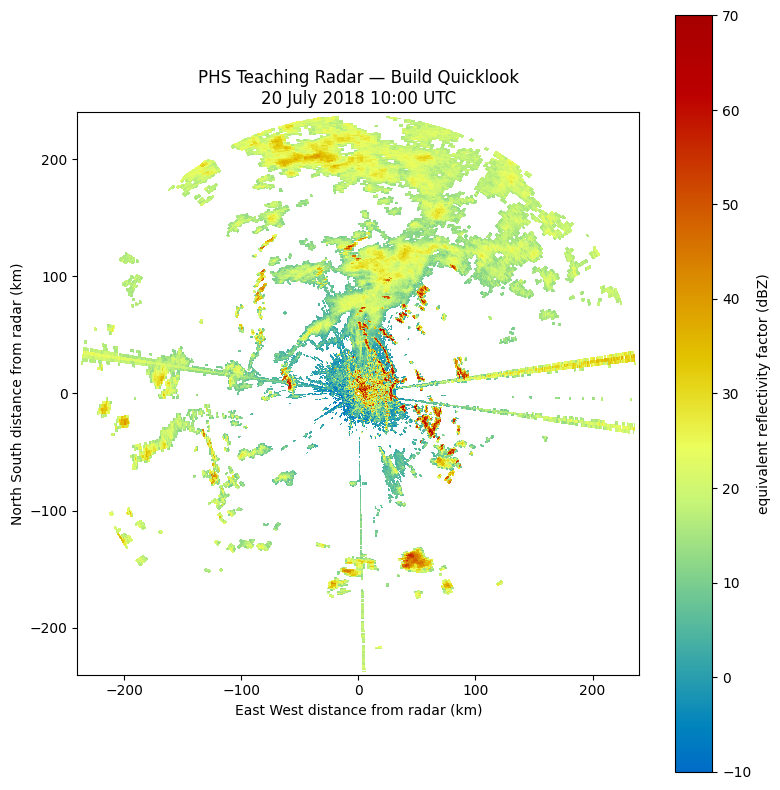

Saved: /content/drive/MyDrive/TMD_Radar_Course_Builder/00_instructor_build/v1/Canonical_TMD_Radar_Course_v1/tmd_radar_course/01_data/metadata/00A_quicklook_PHS_reflectivity.png


In [20]:
# CELL 20 — PPI quicklook

QUICKLOOK_PPI = (
    PATHS["01_data/metadata"]
    / "00A_quicklook_PHS_reflectivity.png"
)

radar = radar_objects[
    RADAR_1000.name
]

reflectivity_field = (
    "reflectivity"
    if "reflectivity"
    in radar.fields
    else (
        "corrected_reflectivity"
        if "corrected_reflectivity"
        in radar.fields
        else None
    )
)

if reflectivity_field is None:
    raise RuntimeError(
        "No reflectivity field is "
        "available for the quicklook."
    )

display_obj = (
    pyart.graph.RadarDisplay(
        radar
    )
)

fig, ax = plt.subplots(
    figsize=(8, 8)
)

display_obj.plot_ppi(
    reflectivity_field,
    sweep=0,
    ax=ax,
    vmin=-10,
    vmax=70,
    title=(
        "PHS Teaching Radar — "
        "Build Quicklook\n"
        "20 July 2018 10:00 UTC"
    ),
)

ax.set_xlim(
    -240,
    240,
)

ax.set_ylim(
    -240,
    240,
)

ax.set_aspect(
    "equal"
)

fig.tight_layout()

fig.savefig(
    QUICKLOOK_PPI,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    QUICKLOOK_PPI,
)

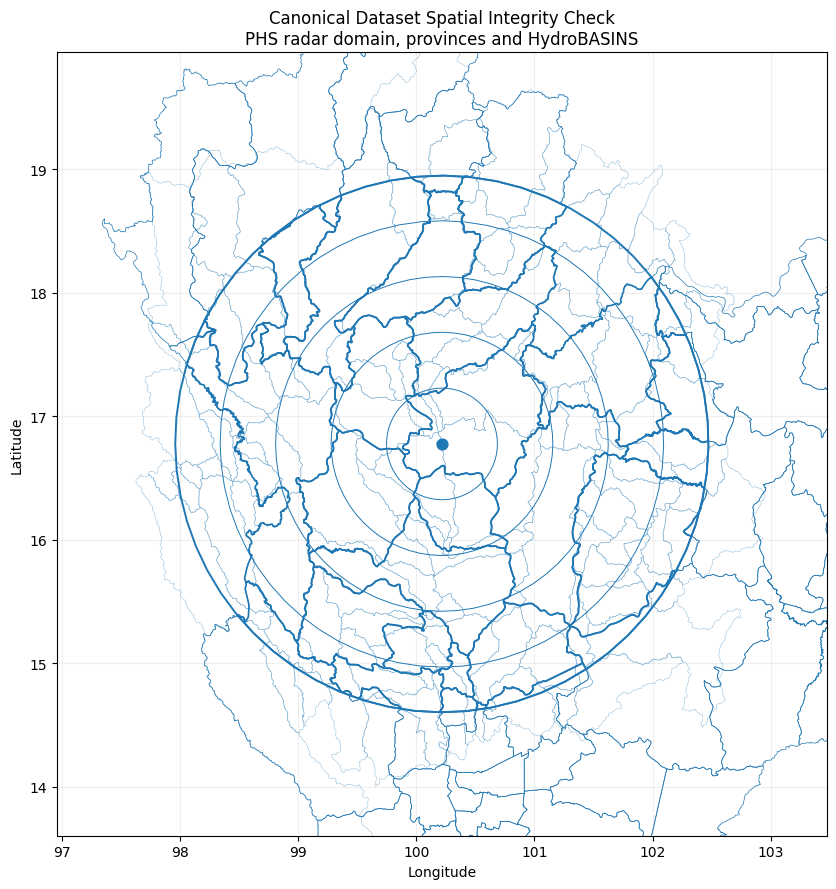

Saved: /content/drive/MyDrive/TMD_Radar_Course_Builder/00_instructor_build/v1/Canonical_TMD_Radar_Course_v1/tmd_radar_course/01_data/metadata/00A_spatial_integrity_map.png


In [21]:
# CELL 21 — Spatial integrity map

INTEGRITY_MAP = (
    PATHS["01_data/metadata"]
    / "00A_spatial_integrity_map.png"
)

fig, ax = plt.subplots(
    figsize=(9, 9)
)

provinces.boundary.plot(
    ax=ax,
    linewidth=0.5,
)

phs_provinces.boundary.plot(
    ax=ax,
    linewidth=1.2,
)

domain_wgs84.boundary.plot(
    ax=ax,
    linewidth=1.4,
)

rings_wgs84.plot(
    ax=ax,
    linewidth=0.7,
)

basins.boundary.plot(
    ax=ax,
    linewidth=0.35,
    alpha=0.5,
)

site_wgs84.plot(
    ax=ax,
    markersize=60,
)

minx, miny, maxx, maxy = (
    domain_wgs84.total_bounds
)

pad = 1.0

ax.set_xlim(
    minx - pad,
    maxx + pad,
)

ax.set_ylim(
    miny - pad,
    maxy + pad,
)

ax.set_xlabel(
    "Longitude"
)

ax.set_ylabel(
    "Latitude"
)

ax.set_title(
    "Canonical Dataset Spatial Integrity Check\n"
    "PHS radar domain, provinces and HydroBASINS"
)

ax.grid(
    alpha=0.2
)

fig.tight_layout()

fig.savefig(
    INTEGRITY_MAP,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    INTEGRITY_MAP,
)

# 0.11 Minimal GeoTIFF smoke test

In [22]:
# CELL 22 — Create and reopen a tiny synthetic georeferenced raster

GEOTIFF_TEST_PATH = (
    PATHS["01_data/metadata"]
    / "00A_geotiff_smoke_test.tif"
)

test_array = np.arange(
    100,
    dtype=np.float32,
).reshape(
    10,
    10,
)

test_transform = from_origin(
    500000,
    1900000,
    1000,
    1000,
)

with rasterio.open(
    GEOTIFF_TEST_PATH,
    "w",
    driver="GTiff",
    height=test_array.shape[0],
    width=test_array.shape[1],
    count=1,
    dtype=test_array.dtype,
    crs=f"EPSG:{UTM_EPSG}",
    transform=test_transform,
    nodata=-9999.0,
) as dst:
    dst.write(
        test_array,
        1,
    )

with rasterio.open(
    GEOTIFF_TEST_PATH
) as src:
    geotiff_smoke_pass = bool(
        src.crs is not None
        and src.width == 10
        and src.height == 10
        and src.transform
        == test_transform
    )

print(
    "GeoTIFF smoke test:",
    geotiff_smoke_pass,
)

GeoTIFF smoke test: True


# 0.12 Generate `course_config.json`

The configuration uses **relative paths**, so it is portable from the instructor build directory to every student's Google Drive.

`setup_status.json` is intentionally not frozen here.  
Notebook `00B` will generate that file after verifying the downloaded student copy.

In [23]:
# CELL 23 — Portable course_config.json

def relative_to_canonical(
    path: Path,
) -> str:
    return str(
        Path(path)
        .relative_to(
            CANONICAL_ROOT
        )
    )


COURSE_CONFIG = {
    "course_name":
        COURSE_NAME,
    "course_version":
        COURSE_VERSION,
    "dataset_version":
        DATASET_VERSION,
    "canonical_student_workspace":
        STUDENT_WORKSPACE_NAME,

    "radar_site": {
        "site_code":
            "PHS",
        "latitude_deg":
            RADAR_LAT,
        "longitude_deg":
            RADAR_LON,
        "altitude_m_msl":
            RADAR_ALT_M,
        "maximum_range_km":
            RADAR_MAX_RANGE_KM,
        "utm_epsg":
            UTM_EPSG,
        "reflectivity_field_for_setup":
            reflectivity_field,
    },

    "hydrobasins": {
        "level":
            HYDROBASINS_LEVEL,
        "source_url":
            HYBAS_URL,
        "number_of_subbasins_in_domain":
            int(
                len(basins)
            ),
    },

    "sounding": {
        "file":
            relative_to_canonical(
                SOUNDING_RAW
            ),
        "processed_profile_csv":
            relative_to_canonical(
                SOUNDING_PROFILE_CSV
            ),
        "pedagogical_only":
            True,
        "collocated_with_radar_event":
            False,
        "isotherm_levels_file":
            relative_to_canonical(
                SOUNDING_LEVELS_JSON
            ),
    },

    "paths": {
        "config":
            "00_config",
        "radar_compressed":
            "01_data/radar/compressed",
        "radar_uf":
            "01_data/radar/uf",
        "sounding_raw":
            "01_data/sounding/raw",
        "sounding_processed":
            "01_data/sounding/processed",
        "dem_raw":
            "01_data/dem/raw",
        "administrative":
            "01_data/gis/administrative",
        "subbasins":
            "01_data/gis/subbasins_phs",
        "radar_site":
            "01_data/gis/radar_site",
        "radar_domain":
            "01_data/gis/radar_domain",
        "metadata":
            "01_data/metadata",
        "outputs":
            "02_outputs",
        "exercises":
            "03_exercises",
        "exports":
            "04_exports",
        "logs":
            "99_logs",
    },

    "files": {
        "radar_1000_uf":
            relative_to_canonical(
                RADAR_1000
            ),
        "radar_1030_uf":
            relative_to_canonical(
                RADAR_1030
            ),
        "dem":
            relative_to_canonical(
                DEM_PATH
            ),
        "sounding_raw":
            relative_to_canonical(
                SOUNDING_RAW
            ),
        "sounding_profile_csv":
            relative_to_canonical(
                SOUNDING_PROFILE_CSV
            ),
        "provinces_full":
            relative_to_canonical(
                PROVINCES_FULL_GPKG
            ),
        "provinces_phs":
            relative_to_canonical(
                PROVINCES_PHS_GPKG
            ),
        "phitsanulok_amphoe":
            relative_to_canonical(
                PHITS_AMPHOE_GPKG
            ),
        "subbasins_phs":
            relative_to_canonical(
                SUBBASINS_GPKG
            ),
        "radar_site":
            relative_to_canonical(
                RADAR_SITE_GPKG
            ),
        "radar_range_rings":
            relative_to_canonical(
                RADAR_RINGS_GPKG
            ),
        "radar_domain":
            relative_to_canonical(
                RADAR_DOMAIN_GPKG
            ),
        "radar_summary":
            relative_to_canonical(
                RADAR_SUMMARY_CSV
            ),
        "radar_fields":
            relative_to_canonical(
                RADAR_FIELDS_CSV
            ),
    },
}

COURSE_CONFIG_PATH = (
    PATHS["00_config"]
    / "course_config.json"
)

write_json(
    COURSE_CONFIG,
    COURSE_CONFIG_PATH,
)

print(
    "Saved:",
    COURSE_CONFIG_PATH,
)

Saved: /content/drive/MyDrive/TMD_Radar_Course_Builder/00_instructor_build/v1/Canonical_TMD_Radar_Course_v1/tmd_radar_course/00_config/course_config.json


# 0.13 Generate legacy `course_paths.py`

Notebook 07 and some revised/legacy lesson variants import `course_paths.py` directly from:

```text
/content/drive/MyDrive/tmd_radar_course/9config/
```

The file generated here therefore uses the final **student** root, not the instructor build path.

`P.SOUNDING` intentionally points to the raw Wyoming text because Notebook 07 parses that text directly.

In [24]:
# CELL 24 — Legacy path contract

COURSE_PATHS_FILE = (
    PATHS["9config"]
    / "course_paths.py"
)

course_paths_text = f"""
from pathlib import Path

ROOT = r"/content/drive/MyDrive/{STUDENT_WORKSPACE_NAME}"
ROOT_PATH = Path(ROOT)

RADAR_1000 = str(
    ROOT_PATH
    / "01_data/radar/uf/PHS240@201807201000.uf"
)

RADAR_1030 = str(
    ROOT_PATH
    / "01_data/radar/uf/PHS240@201807201030.uf"
)

DEM = str(
    ROOT_PATH
    / "01_data/dem/raw/wrl_dem_phk1.tif"
)

# IMPORTANT:
# Notebook 07 expects the raw Wyoming text file.
SOUNDING = str(
    ROOT_PATH
    / "01_data/sounding/raw/sounding_cm.txt"
)

PROVINCE_SHP = str(
    ROOT_PATH
    / "01_data/gis/administrative/thailand_provinces.gpkg"
)

PHITS_SHP = str(
    ROOT_PATH
    / "01_data/gis/administrative/phitsanulok_amphoe.gpkg"
)

BASIN_SHP = str(
    ROOT_PATH
    / "01_data/gis/subbasins_phs/phs_subbasins_hybas{HYBAS_LEVEL_TEXT}.gpkg"
)

RESULTS = str(
    ROOT_PATH
    / "1results"
)

UTM47N = "EPSG:{UTM_EPSG}"


def results_dir(lesson):
    path = (
        ROOT_PATH
        / "1results"
        / str(lesson)
    )
    path.mkdir(
        parents=True,
        exist_ok=True,
    )
    return str(path)
"""

COURSE_PATHS_FILE.write_text(
    textwrap.dedent(
        course_paths_text
    ).strip()
    + "\n",
    encoding="utf-8",
)

print(
    "Saved:",
    COURSE_PATHS_FILE,
)

Saved: /content/drive/MyDrive/TMD_Radar_Course_Builder/00_instructor_build/v1/Canonical_TMD_Radar_Course_v1/tmd_radar_course/9config/course_paths.py


# 0.14 Colab requirements

The existing lessons often install only what they need, but the shared requirements file is retained for compatibility and reproducibility.

In [25]:
# CELL 25 — requirements_colab.txt and environment versions

REQUIREMENTS_FILE = (
    PATHS["00_config"]
    / "requirements_colab.txt"
)

requirements_text = """
arm-pyart==2.2.5
wradlib==2.9.4
geopandas>=1.0
cartopy>=0.24
rasterio>=1.4
shapely>=2.0
pyproj>=3.6
pyogrio>=0.10
metpy>=1.6
cmweather>=0.3
requests>=2.31
tqdm>=4.66
netCDF4
scipy
pandas
matplotlib
psutil
"""

REQUIREMENTS_FILE.write_text(
    textwrap.dedent(
        requirements_text
    ).strip()
    + "\n",
    encoding="utf-8",
)

package_names = [
    "arm-pyart",
    "wradlib",
    "geopandas",
    "rioxarray",
    "cartopy",
    "rasterio",
    "shapely",
    "pyproj",
    "pyogrio",
    "metpy",
    "cmweather",
]

environment_versions = {
    "python":
        sys.version,
    "platform":
        platform.platform(),
    "created_utc":
        utc_now_iso(),
    "packages": {},
}

for package_name in (
    package_names
):
    try:
        environment_versions[
            "packages"
        ][
            package_name
        ] = (
            importlib_metadata
            .version(
                package_name
            )
        )
    except (
        importlib_metadata
        .PackageNotFoundError
    ):
        environment_versions[
            "packages"
        ][
            package_name
        ] = None

ENVIRONMENT_JSON = (
    PATHS["00_config"]
    / "environment_versions.json"
)

write_json(
    environment_versions,
    ENVIRONMENT_JSON,
)

print(
    "Saved requirements and "
    "environment metadata."
)

Saved requirements and environment metadata.


# 0.15 Provenance

In [26]:
# CELL 26 — Consolidate source provenance

download_log = pd.DataFrame(
    download_rows
)

DOWNLOAD_LOG_CSV = (
    PATHS["01_data/metadata"]
    / "source_download_log.csv"
)

download_log.to_csv(
    DOWNLOAD_LOG_CSV,
    index=False,
)

provenance_rows = []

for _, row in (
    download_log.iterrows()
):

    provenance_rows.append({
        "dataset_id":
            row.get(
                "dataset_id"
            ),
        "source_name":
            row.get(
                "source_name"
            ),
        "url_used":
            row.get(
                "url"
            ),
        "source_local_path":
            row.get(
                "path"
            ),
        "source_size_mb":
            row.get(
                "size_mb"
            ),
        "source_sha256":
            row.get(
                "sha256"
            ),
        "detected_payload":
            row.get(
                "detected_payload"
            ),
        "retrieved_or_checked_utc":
            row.get(
                "checked_utc"
            ),
        "redistribution_note": (
            "Review current source license/data-use "
            "conditions before public redistribution."
        ),
    })

provenance_rows.extend([
    {
        "dataset_id":
            "canonical_radar_1000_uf",
        "source_name":
            "Derived by bz2 decompression",
        "url_used":
            None,
        "source_local_path":
            str(RADAR_1000),
        "source_size_mb":
            size_mb(
                RADAR_1000
            ),
        "source_sha256":
            sha256_file(
                RADAR_1000
            ),
        "retrieved_or_checked_utc":
            utc_now_iso(),
        "redistribution_note":
            "Derived from the downloaded source radar volume.",
    },
    {
        "dataset_id":
            "canonical_radar_1030_uf",
        "source_name":
            "Derived by bz2 decompression",
        "url_used":
            None,
        "source_local_path":
            str(RADAR_1030),
        "source_size_mb":
            size_mb(
                RADAR_1030
            ),
        "source_sha256":
            sha256_file(
                RADAR_1030
            ),
        "retrieved_or_checked_utc":
            utc_now_iso(),
        "redistribution_note":
            "Derived from the downloaded source radar volume.",
    },
])

data_provenance = (
    pd.DataFrame(
        provenance_rows
    )
)

DATA_PROVENANCE_CSV = (
    PATHS["01_data/metadata"]
    / "data_provenance.csv"
)

data_provenance.to_csv(
    DATA_PROVENANCE_CSV,
    index=False,
)

display(
    data_provenance
)

,dataset_id,source_name,url_used,source_local_path,source_size_mb,source_sha256,detected_payload,retrieved_or_checked_utc,redistribution_note
0,radar_1000_bz2,nattaponm/train_tmd_radar_basic_1day,None,/content/drive/MyDrive/TMD_Radar_Course_Builde...,2.184772,29a5f2618339b0bf71d88a1970f2285d00fb3285e20b10...,GZIP,2026-08-24T07:22:12.993189+00:00,Review current source license/data-use conditi...
1,radar_1030_bz2,nattaponm/train_tmd_radar_basic_1day,None,/content/drive/MyDrive/TMD_Radar_Course_Builde...,2.140206,59f9a58dd3c7e26880331610f74b29bd3fec9f59eb1183...,GZIP,2026-08-24T07:22:14.496860+00:00,Review current source license/data-use conditi...
2,dem,nattaponm/Beam_blockage_radar_Thai,None,/content/drive/MyDrive/TMD_Radar_Course_Builde...,1.750811,d1a25a917226551d5d1019e688304154a7e15261aadac2...,None,2026-08-24T07:22:15.042844+00:00,Review current source license/data-use conditi...
3,sounding_raw,nattaponm/Python_sounding_Sharppy_Wyomming,None,/content/drive/MyDrive/TMD_Radar_Course_Builde...,0.007201,8ca50e3dffb1c84ecca56676d692de44607f5534571ed9...,None,2026-08-24T07:22:16.369311+00:00,Review current source license/data-use conditi...
4,amphoe_simplified,prasertcbs/thailand_gis,None,/content/drive/MyDrive/TMD_Radar_Course_Builde...,1.728478,ff4175b5bc24b237f0beff8634af2835ea7d7e1002092c...,None,2026-08-24T07:22:16.909829+00:00,Review current source license/data-use conditi...
5,geoboundaries_tha_adm1,geoBoundaries gbOpen,https://github.com/wmgeolab/geoBoundaries/raw/...,/content/drive/MyDrive/TMD_Radar_Course_Builde...,0.963182,841f1250cac868fa966b2089863f01e9c9b4dc9b7fb0d9...,NaN,2026-08-24T07:22:21.981918+00:00,Review current source license/data-use conditi...
6,hydrobasins_asia_level_7,HydroSHEDS HydroBASINS,https://data.hydrosheds.org/file/hydrobasins/s...,/content/drive/MyDrive/TMD_Radar_Course_Builde...,19.995064,3ad218066cc141afe1fceb9bcf64005c1a70ad739c438e...,NaN,2026-08-24T07:22:23.986965+00:00,Review current source license/data-use conditi...
7,canonical_radar_1000_uf,Derived by bz2 decompression,None,/content/drive/MyDrive/TMD_Radar_Course_Builde...,6.913815,1467bc9c69b3b93a3ab163376dd193f562404499c4e1fd...,NaN,2026-08-24T07:22:27.704773+00:00,Derived from the downloaded source radar volume.
8,canonical_radar_1030_uf,Derived by bz2 decompression,None,/content/drive/MyDrive/TMD_Radar_Course_Builde...,6.913815,aaed5f20ee5c441bddce209f47b7d26d6c60155719f174...,NaN,2026-08-24T07:22:27.743679+00:00,Derived from the downloaded source radar volume.


# 0.16 Acceptance tests

A canonical teaching release should fail early when a dependency needed by a later lesson is missing.

Statuses:

- `PASS` — automated test satisfied
- `CHECK` — instructor review required
- `FAIL` — package must not be described as ready

A `CHECK` is intentionally used for redistribution rights because that cannot be validated by code.

In [27]:
# CELL 27 — Build acceptance table

def status_row(
    check,
    observed,
    expected,
    status,
    note="",
):
    return {
        "check":
            check,
        "observed":
            observed,
        "expected":
            expected,
        "status":
            status,
        "note":
            note,
    }


acceptance_rows = []

# Radar readability and dimensions.
for _, row in (
    radar_summary.iterrows()
):

    filename = row[
        "filename"
    ]

    structural_ok = bool(
        row["nsweeps"] > 0
        and row["nrays"] > 0
        and row["ngates"] > 0
        and 50
        <= row["max_range_km"]
        <= 500
    )

    acceptance_rows.append(
        status_row(
            f"Radar structural QC: {filename}",
            (
                f"{row['nsweeps']} sweeps, "
                f"{row['nrays']} rays, "
                f"{row['ngates']} gates, "
                f"{row['max_range_km']:.1f} km"
            ),
            (
                "Positive dimensions and "
                "plausible radar range"
            ),
            (
                "PASS"
                if structural_ok
                else "FAIL"
            ),
        )
    )

    missing = str(
        row[
            "missing_required_fields"
        ]
    ).strip()

    fields_ok = (
        missing == ""
        or missing.lower()
        == "nan"
    )

    acceptance_rows.append(
        status_row(
            f"Required radar fields: {filename}",
            (
                "all present"
                if fields_ok
                else missing
            ),
            ", ".join(
                REQUIRED_RADAR_FIELDS
            ),
            (
                "PASS"
                if fields_ok
                else "FAIL"
            ),
            (
                "These fields are required "
                "across Notebook 01–13."
            ),
        )
    )

# Two radar files should represent the same site.
coord_spread = max(
    radar_summary[
        "latitude_deg"
    ].max()
    - radar_summary[
        "latitude_deg"
    ].min(),
    radar_summary[
        "longitude_deg"
    ].max()
    - radar_summary[
        "longitude_deg"
    ].min(),
)

acceptance_rows.append(
    status_row(
        "Radar-site coordinate consistency",
        coord_spread,
        "<= 0.01 degree between the two volumes",
        (
            "PASS"
            if coord_spread
            <= 0.01
            else "FAIL"
        ),
    )
)

# Sounding
sounding_ok = bool(
    len(sounding_profile)
    >= 10
    and sounding_profile[
        "temperature_c"
    ].notna().sum()
    >= 10
)

acceptance_rows.append(
    status_row(
        "Pedagogical sounding readable",
        (
            f"{len(sounding_profile)} "
            "parsed levels"
        ),
        ">= 10 usable profile levels",
        (
            "PASS"
            if sounding_ok
            else "FAIL"
        ),
        (
            "The sounding is pedagogical only "
            "and is not event-collocated."
        ),
    )
)

# DEM
acceptance_rows.append(
    status_row(
        "DEM readable and georeferenced",
        (
            f"CRS={DEM_CRS}; "
            f"valid_fraction="
            f"{valid_fraction:.3f}"
        ),
        (
            "CRS present, valid pixels present, "
            "PHS location within raster"
        ),
        (
            "PASS"
            if (
                DEM_CRS is not None
                and valid_count > 0
                and radar_inside_dem
            )
            else "FAIL"
        ),
    )
)

# Spatial datasets
for _, row in (
    spatial_qc.iterrows()
):

    spatial_ok = bool(
        row["exists"]
        and row["readable"]
        and str(
            row["crs"]
        ).lower()
        not in [
            "none",
            "nan",
        ]
        and (
            pd.isna(
                row[
                    "invalid_geometry_n"
                ]
            )
            or row[
                "invalid_geometry_n"
            ] == 0
        )
    )

    acceptance_rows.append(
        status_row(
            (
                "Spatial dataset: "
                + row["dataset"]
            ),
            (
                f"readable={row['readable']}; "
                f"CRS={row['crs']}; "
                f"N={row['feature_or_pixel_count']}"
            ),
            (
                "Readable, CRS present, "
                "no invalid vector geometries"
            ),
            (
                "PASS"
                if spatial_ok
                else "FAIL"
            ),
        )
    )

acceptance_rows.append(
    status_row(
        "GeoTIFF round-trip smoke test",
        geotiff_smoke_pass,
        True,
        (
            "PASS"
            if geotiff_smoke_pass
            else "FAIL"
        ),
    )
)

acceptance_rows.append(
    status_row(
        "Redistribution rights reviewed",
        REDISTRIBUTION_RIGHTS_CONFIRMED,
        True,
        (
            "PASS"
            if REDISTRIBUTION_RIGHTS_CONFIRMED
            else "CHECK"
        ),
        (
            "Manual instructor review is required, "
            "especially for TMD radar redistribution."
        ),
    )
)

acceptance_test = pd.DataFrame(
    acceptance_rows
)

ACCEPTANCE_CSV = (
    PATHS["01_data/metadata"]
    / "acceptance_test.csv"
)

acceptance_test.to_csv(
    ACCEPTANCE_CSV,
    index=False,
)

display(
    acceptance_test
)

print(
    "\nStatus counts:"
)

display(
    acceptance_test[
        "status"
    ].value_counts()
)

,check,observed,expected,status,note
0,Radar structural QC: PHS240@201807201000.uf,"4 sweeps, 1924 rays, 240 gates, 240.5 km",Positive dimensions and plausible radar range,PASS,
1,Required radar fields: PHS240@201807201000.uf,all present,"reflectivity, velocity, spectrum_width, correc...",PASS,These fields are required across Notebook 01–13.
2,Radar structural QC: PHS240@201807201030.uf,"4 sweeps, 1924 rays, 240 gates, 240.5 km",Positive dimensions and plausible radar range,PASS,
3,Required radar fields: PHS240@201807201030.uf,all present,"reflectivity, velocity, spectrum_width, correc...",PASS,These fields are required across Notebook 01–13.
4,Radar-site coordinate consistency,0.0,<= 0.01 degree between the two volumes,PASS,
5,Pedagogical sounding readable,70 parsed levels,>= 10 usable profile levels,PASS,The sounding is pedagogical only and is not ev...
6,DEM readable and georeferenced,CRS=EPSG:4326; valid_fraction=1.000,"CRS present, valid pixels present, PHS locatio...",PASS,
7,Spatial dataset: dem,readable=True; CRS=EPSG:4326; N=786480,"Readable, CRS present, no invalid vector geome...",PASS,
8,Spatial dataset: provinces_full,readable=True; CRS=EPSG:4326; N=77,"Readable, CRS present, no invalid vector geome...",PASS,
9,Spatial dataset: provinces_phs,readable=True; CRS=EPSG:4326; N=30,"Readable, CRS present, no invalid vector geome...",PASS,



Status counts:


,count
status,
PASS,16
CHECK,1


# 0.17 Dataset README

This README accompanies the data packages and is separate from the future repository-level course README.

In [28]:
# CELL 28 — README_DATASET.md

README_DATASET = (
    CANONICAL_ROOT
    / "README_DATASET.md"
)

readme_text = f"""
# Canonical TMD Radar Teaching Dataset {DATASET_VERSION}

This dataset was prepared for the course:

**TMD Weather Radar Processing with Open-Source Python**

## Purpose

The dataset freezes the common inputs required by Notebook 01–13 so
students do not need to download external environmental and geospatial
sources independently during class.

## Teaching radar

- Site: Phitsanulok (PHS)
- Latitude: {RADAR_LAT:.6f}
- Longitude: {RADAR_LON:.6f}
- Altitude: {RADAR_ALT_M:.1f} m MSL
- Maximum range in the teaching file: {RADAR_MAX_RANGE_KM:.1f} km
- UTM CRS used by the course: EPSG:{UTM_EPSG}

## Radar files

- `01_data/radar/uf/PHS240@201807201000.uf`
- `01_data/radar/uf/PHS240@201807201030.uf`

Source repository used by the instructor builder:

`nattaponm/train_tmd_radar_basic_1day`

The source filenames use a `.uf.bz2` suffix, but the builder does
not assume that the byte stream is bzip2. It inspects magic bytes and
supports true bzip2, gzip, or already-uncompressed radar binary before
materializing a canonical `.uf` file.

The instructor builder then verifies that both canonical UF volumes can
be opened by Py-ART and checks for the radar fields required by the course.

## DEM

Canonical file:

`01_data/dem/raw/wrl_dem_phk1.tif`

Source repository:

`nattaponm/Beam_blockage_radar_Thai`

The builder checks raster readability, CRS, valid pixels, and whether
the PHS radar location falls inside the DEM extent.

## Sounding

Raw canonical file:

`01_data/sounding/raw/sounding_cm.txt`

Source repository:

`nattaponm/Python_sounding_Sharppy_Wyomming`

Important limitation:

The Chiang Mai sounding is a pedagogical profile and is NOT collocated
in time or space with the PHS radar event. It is retained because the
existing polarimetric lesson uses it to demonstrate temperature-profile
mapping and isotherm levels.

Do not use this profile to describe the true environmental state of the
20 July 2018 PHS radar event.

## Administrative boundaries

Thailand ADM1 was retrieved through the geoBoundaries gbOpen API.
The API metadata used during the build are stored in:

`01_data/metadata/geoboundaries_adm1_source_metadata.json`

A Phitsanulok amphoe layer is additionally frozen from
`prasertcbs/thailand_gis` to preserve compatibility with legacy lessons.

## HydroBASINS

The instructor builder downloads HydroBASINS Asia level
{HYDROBASINS_LEVEL} and retains only polygons intersecting the PHS radar
domain in the canonical student dataset.

Canonical file:

`01_data/gis/subbasins_phs/phs_subbasins_hybas{HYBAS_LEVEL_TEXT}.gpkg`

## Reproducibility

See:

- `01_data/metadata/data_provenance.csv`
- `01_data/metadata/source_download_log.csv`
- `01_data/metadata/radar_file_summary.csv`
- `01_data/metadata/radar_field_inventory.csv`
- `01_data/metadata/dem_qc.csv`
- `01_data/metadata/spatial_dataset_qc.csv`
- `01_data/metadata/acceptance_test.csv`
- `00_config/dataset_manifest.csv`

## Student-use principle

Students should start with Notebook `00B`, which downloads the frozen
course packages from the course GitHub repository, verifies SHA256,
installs the dataset into:

`/content/drive/MyDrive/tmd_radar_course`

and creates `setup_status.json`.

Notebook 01–13 should not re-download these external source datasets.

## Redistribution and attribution

Before publicly redistributing the packages, review the current license
and data-use conditions of every original source. Technical preparation
by 00A is not a substitute for permission to redistribute third-party data.
"""

README_DATASET.write_text(
    textwrap.dedent(
        readme_text
    ).strip()
    + "\n",
    encoding="utf-8",
)

print(
    "Saved:",
    README_DATASET,
)

Saved: /content/drive/MyDrive/TMD_Radar_Course_Builder/00_instructor_build/v1/Canonical_TMD_Radar_Course_v1/tmd_radar_course/README_DATASET.md


# 0.18 Canonical file manifest

In [29]:
# CELL 29 — Build deterministic file manifest

manifest_rows = []

for path in sorted(
    CANONICAL_ROOT.rglob("*")
):

    if not path.is_file():
        continue

    # Manifest will be generated after this scan.
    if (
        path.name
        == "dataset_manifest.csv"
    ):
        continue

    manifest_rows.append({
        "relative_path":
            str(
                path.relative_to(
                    CANONICAL_ROOT
                )
            ),
        "size_bytes":
            path.stat().st_size,
        "size_mb":
            size_mb(path),
        "sha256":
            sha256_file(path),
    })

dataset_manifest = pd.DataFrame(
    manifest_rows
)

DATASET_MANIFEST_CSV = (
    PATHS["00_config"]
    / "dataset_manifest.csv"
)

dataset_manifest.to_csv(
    DATASET_MANIFEST_CSV,
    index=False,
)

display(
    dataset_manifest
)

,relative_path,size_bytes,size_mb,sha256
0,00_config/course_config.json,2512,0.002396,8f573739f570af724440767c6195bdefc3416153e56417...
1,00_config/environment_versions.json,468,0.000446,b43b60f9568792ef5ca6a9796f122a508e337e10783715...
2,00_config/requirements_colab.txt,205,0.000196,8067df149a8419e0e8f2e2cda3d822f78fe040e551f6e5...
3,01_data/dem/raw/wrl_dem_phk1.tif,1835858,1.750811,d1a25a917226551d5d1019e688304154a7e15261aadac2...
4,01_data/gis/administrative/phitsanulok_amphoe....,147456,0.140625,e548c29a9620722b603cbb3696e24b1488620a215522f2...
5,01_data/gis/administrative/phs_radar_provinces...,286720,0.273438,eaefca17ecd6fc8778988e29b2aa113f160331bec7d28a...
6,01_data/gis/administrative/thailand_provinces....,749568,0.714844,35b164901847d5e96077ec3b09dd2c1a63a6654ef445d3...
7,01_data/gis/radar_domain/phs_radar_domain.gpkg,98304,0.093750,5a5af021b995181931cfa3a93d844aa0cde74856a8ce16...
8,01_data/gis/radar_domain/phs_radar_range_rings...,106496,0.101562,2910fcfd8d1ece267dc668a577fba514a89023d8af485d...
9,01_data/gis/radar_site/phs_radar_site.gpkg,98304,0.093750,f80128d97cde16655db609ae2e8ef5b7f240009a9d2ec9...


# 0.19 Package design

Three packages are created so GitHub file-size limits can be checked independently:

```text
TMD_Radar_Core_v1.zip
    radar UF + sounding

TMD_Radar_Spatial_v1.zip
    DEM + GIS

TMD_Radar_Metadata_v1.zip
    00_config + metadata + legacy course_paths + dataset README
```

The ZIPs preserve the top-level folder:

```text
tmd_radar_course/
```

so 00B can merge them safely into a temporary staging area before copying the verified workspace to Google Drive.

In [30]:
# CELL 30 — ZIP package helper

def zip_selected_paths(
    output_zip: Path,
    relative_roots: list[str],
):

    output_zip = Path(
        output_zip
    )

    if (
        output_zip.exists()
        and FORCE_REBUILD_PACKAGES
    ):
        output_zip.unlink()

    with zipfile.ZipFile(
        output_zip,
        "w",
        compression=zipfile.ZIP_DEFLATED,
        compresslevel=6,
    ) as archive:

        for relative_root in (
            relative_roots
        ):

            source = (
                CANONICAL_ROOT
                / relative_root
            )

            if not source.exists():
                raise FileNotFoundError(
                    "Package input missing: "
                    + str(source)
                )

            if source.is_file():

                arcname = (
                    Path(
                        STUDENT_WORKSPACE_NAME
                    )
                    / source.relative_to(
                        CANONICAL_ROOT
                    )
                )

                archive.write(
                    source,
                    arcname=str(
                        arcname
                    ),
                )

            else:

                for file_path in sorted(
                    source.rglob("*")
                ):

                    if not file_path.is_file():
                        continue

                    arcname = (
                        Path(
                            STUDENT_WORKSPACE_NAME
                        )
                        / file_path.relative_to(
                            CANONICAL_ROOT
                        )
                    )

                    archive.write(
                        file_path,
                        arcname=str(
                            arcname
                        ),
                    )

    return output_zip


CORE_ZIP = (
    GITHUB_READY_DIR
    / (
        "TMD_Radar_Core_"
        + DATASET_VERSION
        + ".zip"
    )
)

SPATIAL_ZIP = (
    GITHUB_READY_DIR
    / (
        "TMD_Radar_Spatial_"
        + DATASET_VERSION
        + ".zip"
    )
)

METADATA_ZIP = (
    GITHUB_READY_DIR
    / (
        "TMD_Radar_Metadata_"
        + DATASET_VERSION
        + ".zip"
    )
)

zip_selected_paths(
    CORE_ZIP,
    [
        "01_data/radar/uf",
        "01_data/sounding/raw",
        "01_data/sounding/processed",
    ],
)

zip_selected_paths(
    SPATIAL_ZIP,
    [
        "01_data/dem",
        "01_data/gis",
    ],
)

zip_selected_paths(
    METADATA_ZIP,
    [
        "00_config",
        "01_data/metadata",
        "9config",
        "README_DATASET.md",
    ],
)

for path in [
    CORE_ZIP,
    SPATIAL_ZIP,
    METADATA_ZIP,
]:
    print(
        path.name,
        f"{size_mb(path):.2f} MB",
    )

TMD_Radar_Core_v1.zip 4.28 MB
TMD_Radar_Spatial_v1.zip 1.71 MB
TMD_Radar_Metadata_v1.zip 1.09 MB


# 0.20 Verify packages independently

In [31]:
# CELL 31 — Package hashes and contents

package_specs = [
    {
        "package_id":
            "core",
        "filename":
            CORE_ZIP.name,
        "path":
            CORE_ZIP,
        "purpose":
            "Radar UF volumes and pedagogical sounding",
        "required":
            True,
    },
    {
        "package_id":
            "spatial",
        "filename":
            SPATIAL_ZIP.name,
        "path":
            SPATIAL_ZIP,
        "purpose":
            "DEM and GIS layers",
        "required":
            True,
    },
    {
        "package_id":
            "metadata",
        "filename":
            METADATA_ZIP.name,
        "path":
            METADATA_ZIP,
        "purpose":
            "Configuration, metadata, provenance and legacy paths",
        "required":
            True,
    },
]

package_rows = []

for spec in package_specs:

    path = Path(
        spec["path"]
    )

    zip_ok = False
    top_level_ok = False
    member_count = 0

    try:
        with zipfile.ZipFile(
            path,
            "r",
        ) as archive:

            bad_member = (
                archive.testzip()
            )

            names = (
                archive.namelist()
            )

            member_count = len(
                names
            )

            zip_ok = (
                bad_member is None
            )

            top_level_ok = all(
                name.startswith(
                    STUDENT_WORKSPACE_NAME
                    + "/"
                )
                for name in names
            )

    except Exception:
        zip_ok = False

    mb = size_mb(
        path
    )

    package_rows.append({
        "package_id":
            spec["package_id"],
        "filename":
            spec["filename"],
        "dataset_version":
            DATASET_VERSION,
        "purpose":
            spec["purpose"],
        "required":
            spec["required"],
        "size_bytes":
            path.stat().st_size,
        "size_mb":
            mb,
        "sha256":
            sha256_file(
                path
            ),
        "zip_integrity_pass":
            zip_ok,
        "top_level_folder_pass":
            top_level_ok,
        "member_count":
            member_count,
        "under_95_mb":
            (
                mb
                < GITHUB_PACKAGE_LIMIT_MB
            ),
    })

dataset_packages = pd.DataFrame(
    package_rows
)

DATASET_PACKAGES_CSV = (
    GITHUB_READY_DIR
    / "dataset_packages.csv"
)

dataset_packages.to_csv(
    DATASET_PACKAGES_CSV,
    index=False,
)

display(
    dataset_packages
)

,package_id,filename,dataset_version,purpose,required,size_bytes,size_mb,sha256,zip_integrity_pass,top_level_folder_pass,member_count,under_95_mb
0,core,TMD_Radar_Core_v1.zip,v1,Radar UF volumes and pedagogical sounding,True,4490103,4.282096,a398f713eeca32051283607abd247b820c842c18df63f4...,True,True,4,True
1,spatial,TMD_Radar_Spatial_v1.zip,v1,DEM and GIS layers,True,1790610,1.707659,d317aef04554cc825c8426192d3099316c958aff36043d...,True,True,8,True
2,metadata,TMD_Radar_Metadata_v1.zip,v1,"Configuration, metadata, provenance and legacy...",True,1144357,1.091344,f18d5e44418c624b5fa75c34253596bf0a5b58766d3e22...,True,True,19,True


In [32]:
# CELL 32 — SHA256 sidecar

SHA256_FILE = (
    GITHUB_READY_DIR
    / "dataset_packages.sha256"
)

sha_lines = [
    (
        f"{row['sha256']}  "
        f"{row['filename']}"
    )
    for _, row in (
        dataset_packages
        .iterrows()
    )
]

SHA256_FILE.write_text(
    "\n".join(
        sha_lines
    )
    + "\n",
    encoding="utf-8",
)

print(
    SHA256_FILE.read_text(
        encoding="utf-8"
    )
)

a398f713eeca32051283607abd247b820c842c18df63f425d209b1693752ff83  TMD_Radar_Core_v1.zip
d317aef04554cc825c8426192d3099316c958aff36043d3b38cb409608ffa084  TMD_Radar_Spatial_v1.zip
f18d5e44418c624b5fa75c34253596bf0a5b58766d3e2243722a57633c16a256  TMD_Radar_Metadata_v1.zip



# 0.21 Simulate a fresh student extraction

This is a high-value test.

The packages are extracted into a clean temporary directory, merged exactly as 00B will do, and every required file is checked again.

This catches packaging mistakes that are invisible when testing only the instructor build tree.

In [33]:
# CELL 33 — Fresh extraction simulation

SIMULATION_ROOT = (
    TEMP_DIR
    / "student_install_simulation"
)

if SIMULATION_ROOT.exists():
    shutil.rmtree(
        SIMULATION_ROOT
    )

SIMULATION_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

for package in [
    CORE_ZIP,
    SPATIAL_ZIP,
    METADATA_ZIP,
]:
    safe_extract_zip(
        package,
        SIMULATION_ROOT,
        clean=False,
    )

SIM_STUDENT_ROOT = (
    SIMULATION_ROOT
    / STUDENT_WORKSPACE_NAME
)

required_simulation_paths = {
    "course_config":
        SIM_STUDENT_ROOT
        / "00_config/course_config.json",

    "course_paths":
        SIM_STUDENT_ROOT
        / "9config/course_paths.py",

    "radar_1000":
        SIM_STUDENT_ROOT
        / (
            "01_data/radar/uf/"
            "PHS240@201807201000.uf"
        ),

    "radar_1030":
        SIM_STUDENT_ROOT
        / (
            "01_data/radar/uf/"
            "PHS240@201807201030.uf"
        ),

    "dem":
        SIM_STUDENT_ROOT
        / (
            "01_data/dem/raw/"
            "wrl_dem_phk1.tif"
        ),

    "sounding":
        SIM_STUDENT_ROOT
        / (
            "01_data/sounding/raw/"
            "sounding_cm.txt"
        ),

    "provinces_full":
        SIM_STUDENT_ROOT
        / (
            "01_data/gis/administrative/"
            "thailand_provinces.gpkg"
        ),

    "provinces_phs":
        SIM_STUDENT_ROOT
        / (
            "01_data/gis/administrative/"
            "phs_radar_provinces.gpkg"
        ),

    "phitsanulok_amphoe":
        SIM_STUDENT_ROOT
        / (
            "01_data/gis/administrative/"
            "phitsanulok_amphoe.gpkg"
        ),

    "subbasins":
        SIM_STUDENT_ROOT
        / (
            "01_data/gis/subbasins_phs/"
            f"phs_subbasins_hybas{HYBAS_LEVEL_TEXT}.gpkg"
        ),

    "radar_site":
        SIM_STUDENT_ROOT
        / (
            "01_data/gis/radar_site/"
            "phs_radar_site.gpkg"
        ),

    "radar_range_rings":
        SIM_STUDENT_ROOT
        / (
            "01_data/gis/radar_domain/"
            "phs_radar_range_rings.gpkg"
        ),

    "radar_domain":
        SIM_STUDENT_ROOT
        / (
            "01_data/gis/radar_domain/"
            "phs_radar_domain.gpkg"
        ),
}

simulation_rows = []

for key, path in (
    required_simulation_paths
    .items()
):

    simulation_rows.append({
        "resource":
            key,
        "relative_path":
            str(
                path.relative_to(
                    SIM_STUDENT_ROOT
                )
            ),
        "exists":
            path.exists(),
        "size_mb":
            (
                size_mb(path)
                if path.exists()
                else np.nan
            ),
    })

simulation_test = (
    pd.DataFrame(
        simulation_rows
    )
)

display(
    simulation_test
)

if not (
    simulation_test[
        "exists"
    ].all()
):
    raise RuntimeError(
        "Fresh-package extraction is "
        "missing one or more required files."
    )

,resource,relative_path,exists,size_mb
0,course_config,00_config/course_config.json,True,0.002396
1,course_paths,9config/course_paths.py,True,0.000978
2,radar_1000,01_data/radar/uf/PHS240@201807201000.uf,True,6.913815
3,radar_1030,01_data/radar/uf/PHS240@201807201030.uf,True,6.913815
4,dem,01_data/dem/raw/wrl_dem_phk1.tif,True,1.750811
5,sounding,01_data/sounding/raw/sounding_cm.txt,True,0.007201
6,provinces_full,01_data/gis/administrative/thailand_provinces....,True,0.714844
7,provinces_phs,01_data/gis/administrative/phs_radar_provinces...,True,0.273438
8,phitsanulok_amphoe,01_data/gis/administrative/phitsanulok_amphoe....,True,0.140625
9,subbasins,01_data/gis/subbasins_phs/phs_subbasins_hybas0...,True,0.695312


In [34]:
# CELL 34 — Scientific reopen tests on simulated student copy

simulation_reopen_rows = []

# Radar
for key in [
    "radar_1000",
    "radar_1030",
]:

    path = (
        required_simulation_paths[
            key
        ]
    )

    try:
        sim_radar = pyart.io.read(
            str(path)
        )

        missing = [
            field
            for field
            in REQUIRED_RADAR_FIELDS
            if field
            not in sim_radar.fields
        ]

        simulation_reopen_rows.append({
            "resource":
                key,
            "readable":
                True,
            "detail":
                (
                    "required fields present"
                    if not missing
                    else (
                        "missing: "
                        + ", ".join(
                            missing
                        )
                    )
                ),
            "status":
                (
                    "PASS"
                    if not missing
                    else "FAIL"
                ),
        })

    except Exception as exc:

        simulation_reopen_rows.append({
            "resource":
                key,
            "readable":
                False,
            "detail":
                str(exc),
            "status":
                "FAIL",
        })


# Raster
try:
    with rasterio.open(
        required_simulation_paths[
            "dem"
        ]
    ) as src:

        raster_ok = (
            src.crs is not None
            and src.width > 0
            and src.height > 0
        )

    simulation_reopen_rows.append({
        "resource":
            "dem",
        "readable":
            raster_ok,
        "detail":
            str(
                src.crs
            ),
        "status":
            (
                "PASS"
                if raster_ok
                else "FAIL"
            ),
    })

except Exception as exc:

    simulation_reopen_rows.append({
        "resource":
            "dem",
        "readable":
            False,
        "detail":
            str(exc),
        "status":
            "FAIL",
    })


# Vectors
for key in [
    "provinces_full",
    "provinces_phs",
    "phitsanulok_amphoe",
    "subbasins",
    "radar_site",
    "radar_range_rings",
    "radar_domain",
]:

    path = (
        required_simulation_paths[
            key
        ]
    )

    try:
        gdf = gpd.read_file(
            path
        )

        ok = bool(
            gdf.crs is not None
            and len(gdf) > 0
            and (
                ~gdf.geometry.is_valid
            ).sum() == 0
        )

        simulation_reopen_rows.append({
            "resource":
                key,
            "readable":
                True,
            "detail":
                (
                    f"N={len(gdf)}, "
                    f"CRS={gdf.crs}"
                ),
            "status":
                (
                    "PASS"
                    if ok
                    else "FAIL"
                ),
        })

    except Exception as exc:

        simulation_reopen_rows.append({
            "resource":
                key,
            "readable":
                False,
            "detail":
                str(exc),
            "status":
                "FAIL",
        })


simulation_reopen = pd.DataFrame(
    simulation_reopen_rows
)

display(
    simulation_reopen
)

,resource,readable,detail,status
0,radar_1000,True,required fields present,PASS
1,radar_1030,True,required fields present,PASS
2,dem,True,EPSG:4326,PASS
3,provinces_full,True,"N=77, CRS=EPSG:4326",PASS
4,provinces_phs,True,"N=30, CRS=EPSG:4326",PASS
5,phitsanulok_amphoe,True,"N=9, CRS=EPSG:4326",PASS
6,subbasins,True,"N=97, CRS=EPSG:4326",PASS
7,radar_site,True,"N=1, CRS=EPSG:4326",PASS
8,radar_range_rings,True,"N=4, CRS=EPSG:4326",PASS
9,radar_domain,True,"N=1, CRS=EPSG:4326",PASS


# 0.22 Final release decision

In [35]:
# CELL 35 — Combine build, package and simulation status

final_rows = []

# Copy build acceptance results.
for _, row in (
    acceptance_test.iterrows()
):

    final_rows.append({
        "stage":
            "build_acceptance",
        "check":
            row["check"],
        "status":
            row["status"],
        "detail":
            row["observed"],
    })

# Package checks.
for _, row in (
    dataset_packages.iterrows()
):

    package_ok = bool(
        row[
            "zip_integrity_pass"
        ]
        and row[
            "top_level_folder_pass"
        ]
        and row[
            "under_95_mb"
        ]
    )

    final_rows.append({
        "stage":
            "package",
        "check":
            row[
                "filename"
            ],
        "status":
            (
                "PASS"
                if package_ok
                else "FAIL"
            ),
        "detail":
            (
                f"{row['size_mb']:.2f} MB; "
                f"zip={row['zip_integrity_pass']}; "
                f"top_level={row['top_level_folder_pass']}; "
                f"under95={row['under_95_mb']}"
            ),
    })

# Simulated student copy.
for _, row in (
    simulation_reopen.iterrows()
):

    final_rows.append({
        "stage":
            "fresh_student_simulation",
        "check":
            row["resource"],
        "status":
            row["status"],
        "detail":
            row["detail"],
    })


final_acceptance = (
    pd.DataFrame(
        final_rows
    )
)

FINAL_ACCEPTANCE_CSV = (
    GITHUB_READY_DIR
    / "final_acceptance_test.csv"
)

final_acceptance.to_csv(
    FINAL_ACCEPTANCE_CSV,
    index=False,
)

display(
    final_acceptance
)

fail_count = int(
    (
        final_acceptance[
            "status"
        ]
        == "FAIL"
    ).sum()
)

check_count = int(
    (
        final_acceptance[
            "status"
        ]
        == "CHECK"
    ).sum()
)

if fail_count > 0:
    RELEASE_STATUS = (
        "NOT_READY"
    )
elif check_count > 0:
    RELEASE_STATUS = (
        "REVIEW_REQUIRED"
    )
else:
    RELEASE_STATUS = (
        "GITHUB_READY"
    )

print(
    "\n"
    + "=" * 72
)

print(
    "FINAL RELEASE STATUS:",
    RELEASE_STATUS,
)

print(
    "FAIL :",
    fail_count,
)

print(
    "CHECK:",
    check_count,
)

print(
    "=" * 72
)

,stage,check,status,detail
0,build_acceptance,Radar structural QC: PHS240@201807201000.uf,PASS,"4 sweeps, 1924 rays, 240 gates, 240.5 km"
1,build_acceptance,Required radar fields: PHS240@201807201000.uf,PASS,all present
2,build_acceptance,Radar structural QC: PHS240@201807201030.uf,PASS,"4 sweeps, 1924 rays, 240 gates, 240.5 km"
3,build_acceptance,Required radar fields: PHS240@201807201030.uf,PASS,all present
4,build_acceptance,Radar-site coordinate consistency,PASS,0.0
5,build_acceptance,Pedagogical sounding readable,PASS,70 parsed levels
6,build_acceptance,DEM readable and georeferenced,PASS,CRS=EPSG:4326; valid_fraction=1.000
7,build_acceptance,Spatial dataset: dem,PASS,readable=True; CRS=EPSG:4326; N=786480
8,build_acceptance,Spatial dataset: provinces_full,PASS,readable=True; CRS=EPSG:4326; N=77
9,build_acceptance,Spatial dataset: provinces_phs,PASS,readable=True; CRS=EPSG:4326; N=30



FINAL RELEASE STATUS: REVIEW_REQUIRED
FAIL : 0
CHECK: 1


In [36]:
# CELL 36 — Final build summary

final_build_summary = pd.DataFrame([
    {
        "course_name":
            COURSE_NAME,
        "course_version":
            COURSE_VERSION,
        "dataset_version":
            DATASET_VERSION,
        "release_status":
            RELEASE_STATUS,
        "fail_count":
            fail_count,
        "check_count":
            check_count,
        "radar_site":
            "PHS",
        "radar_latitude":
            RADAR_LAT,
        "radar_longitude":
            RADAR_LON,
        "radar_utm_epsg":
            UTM_EPSG,
        "hydrobasins_level":
            HYDROBASINS_LEVEL,
        "package_count":
            len(
                dataset_packages
            ),
        "github_ready_dir":
            str(
                GITHUB_READY_DIR
            ),
        "built_utc":
            utc_now_iso(),
    }
])

FINAL_BUILD_SUMMARY_CSV = (
    GITHUB_READY_DIR
    / "final_build_summary.csv"
)

final_build_summary.to_csv(
    FINAL_BUILD_SUMMARY_CSV,
    index=False,
)

display(
    final_build_summary
)

,course_name,course_version,dataset_version,release_status,fail_count,check_count,radar_site,radar_latitude,radar_longitude,radar_utm_epsg,hydrobasins_level,package_count,github_ready_dir,built_utc
0,TMD Weather Radar Processing with Open-Source ...,1.0.0,v1,REVIEW_REQUIRED,0,1,PHS,16.775408,100.217964,32647,7,3,/content/drive/MyDrive/TMD_Radar_Course_Builde...,2026-08-24T07:22:31.252680+00:00


# 0.23 Copy human-readable metadata to GitHub-ready folder

The instructor should upload the files listed by the final cell after all `FAIL` items are resolved and the manual `CHECK` has been reviewed.

In [37]:
# CELL 37 — Copy README and key manifests beside the ZIP packages

for source, target_name in [
    (
        README_DATASET,
        "README_DATASET.md",
    ),
    (
        DATASET_MANIFEST_CSV,
        "dataset_manifest.csv",
    ),
    (
        DATA_PROVENANCE_CSV,
        "data_provenance.csv",
    ),
    (
        ACCEPTANCE_CSV,
        "build_acceptance_test.csv",
    ),
]:

    shutil.copy2(
        source,
        GITHUB_READY_DIR
        / target_name,
    )

print(
    "GitHub-ready support files copied."
)

GitHub-ready support files copied.


In [38]:
# CELL 38 — Final GitHub upload inventory

github_ready_rows = []

for path in sorted(
    GITHUB_READY_DIR.iterdir()
):

    if not path.is_file():
        continue

    github_ready_rows.append({
        "filename":
            path.name,
        "size_mb":
            size_mb(path),
        "sha256":
            sha256_file(path),
    })

github_ready_inventory = (
    pd.DataFrame(
        github_ready_rows
    )
)

GITHUB_READY_INVENTORY_CSV = (
    GITHUB_READY_DIR
    / "github_ready_inventory.csv"
)

# Save after creating the current table; the inventory
# intentionally does not include its own checksum row.
github_ready_inventory.to_csv(
    GITHUB_READY_INVENTORY_CSV,
    index=False,
)

display(
    github_ready_inventory
)

print(
    "\nUpload directory:"
)

print(
    GITHUB_READY_DIR
)

print(
    "\nCurrent release status:",
    RELEASE_STATUS,
)

if RELEASE_STATUS == "REVIEW_REQUIRED":
    print(
        "\nThe automated data tests passed, "
        "but at least one manual review remains."
    )

    print(
        "Most importantly, set "
        "REDISTRIBUTION_RIGHTS_CONFIRMED=True "
        "only after reviewing current source "
        "redistribution conditions, then rerun "
        "the acceptance/package section."
    )

elif RELEASE_STATUS == "GITHUB_READY":

    print(
        "\nThe canonical release passed "
        "all configured tests."
    )

    print(
        "Next step: upload the GitHub-ready "
        "files to the course repository, then "
        "build Notebook 00B using the actual "
        "repository raw URLs."
    )

else:

    print(
        "\nDo not publish the packages yet. "
        "Resolve FAIL rows first."
    )

,filename,size_mb,sha256
0,README_DATASET.md,0.003256,f231e6b434278a1ab69313d9826c3bcd85105ebfe2f120...
1,TMD_Radar_Core_v1.zip,4.282096,a398f713eeca32051283607abd247b820c842c18df63f4...
2,TMD_Radar_Metadata_v1.zip,1.091344,f18d5e44418c624b5fa75c34253596bf0a5b58766d3e22...
3,TMD_Radar_Spatial_v1.zip,1.707659,d317aef04554cc825c8426192d3099316c958aff36043d...
4,build_acceptance_test.csv,0.002267,883ca38f348d0ab2521429af1dcd5198e1e27dbfabba62...
5,data_provenance.csv,0.003457,9ec1316213dc4896e1d10805f2c31156175b5725590dfc...
6,dataset_manifest.csv,0.003764,1789f5de2a7b16059fa619a7b03f9b103f6a55a5a97bbb...
7,dataset_packages.csv,0.000673,93d1e30ae7ccb6839f4380f59238246b60f5725db10c7e...
8,dataset_packages.sha256,0.000258,d205a173e36b6f6208be44f95fbbbecb4b17ca7708ba57...
9,final_acceptance_test.csv,0.002221,f744b7eeb5bd9ce049097935bb9c8d956350ea1e5d65b8...



Upload directory:
/content/drive/MyDrive/TMD_Radar_Course_Builder/01_GitHub_ready/v1

Current release status: REVIEW_REQUIRED

The automated data tests passed, but at least one manual review remains.
Most importantly, set REDISTRIBUTION_RIGHTS_CONFIRMED=True only after reviewing current source redistribution conditions, then rerun the acceptance/package section.


---

# Instructor checklist after running 00A

Before building Notebook `00B`, verify:

1. `final_acceptance_test.csv` contains no `FAIL`.
2. Every ZIP is below the 95 MB operational threshold.
3. `00A_quicklook_PHS_reflectivity.png` visually resembles a valid PPI.
4. `00A_spatial_integrity_map.png` shows the PHS radar domain in the expected part of Thailand.
5. The two UF files reopen after a **fresh package extraction**.
6. The DEM and all GeoPackages reopen.
7. The raw `sounding_cm.txt` is preserved because Notebook 07 parses that format directly.
8. The manual redistribution/data-use review is completed before public upload.

After uploading the generated GitHub-ready files, create:

```text
00B_get_radar_course_dataset_from_GitHub.ipynb
```

using the actual repository name and package URLs.

`00B` will then:

```text
GitHub packages
    ↓
SHA256 verification
    ↓
safe extraction in /content
    ↓
fresh-file validation
    ↓
copy to MyDrive/tmd_radar_course
    ↓
create setup_status.json
    ↓
create output/exercise/export folders for NB01–NB13
    ↓
READY FOR NOTEBOOK 01
```